# Setup

In [59]:
%matplotlib inline

import os, sys, pickle, warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.ndimage import uniform_filter1d

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")

import src.utils as utils
from src.utils import set_font_size
from src.fmri_io import get_paths, load_fmri_data

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# set_font_size is imported from src.utils

# Load data

In [60]:
# path to the pickle file produced by biornn_results_dynamics_trajectory.py
model_params_name = 'model_params_202606d'
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = os.path.join('/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model', model_params_name)
        # modeldir = os.path.join('/Volumes/Sabrent_2TB/rutgers/neuro_rnn/data', model_params_name)
        # outdir = modeldir
        outdir = '/Users/ahmad/Desktop/figs'
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
        outdir = modeldir
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = modeldir

results_file = os.path.join(modeldir, f'training_trajectory_{model_params_name}.pkl')
with open(results_file, 'rb') as f:
    data = pickle.load(f)

save_figs = True
# outdir = modeldir

# set to an integer to limit plots to epochs <= this value; None = plot all
max_plot_epoch = None

# set to a list of CSV row numbers to include (matches the script's --rows); None = plot all
# (run the "Unpack results" cell to see available rows)
plot_models = None

print(f'Loaded: {results_file}')
print(f'Models: {len(data["results"])}')
print(f'Args: {data["args"]}')

Loaded: /Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model/model_params_202606d/training_trajectory_model_params_202606d.pkl
Models: 3
Args: {'model_params': 'model_params_202606d', 'rows': [0, 1, 2], 'n_epochs': 100, 'n_trials': 100, 'n_fmri_subj': 100, 'n_pc': 5, 'n_jobs': -1, 'max_epoch': 40000, 'max_runs': 100, 'outdir': None, 'skip_fmri': False, 'skip_topology': False, 'node_subsets': 'bystanders', 'rc_perms': 1000, 'test_seed': 0}


# Unpack results

In [61]:
model_params = data['model_params']
fmri_baselines = data['fmri_intersubj_baselines']
results = data['results']
n_models = len(results)

# derive task/kernel structure
task_names = list(model_params.task_no_modifier.unique())
n_tasks = len(task_names)
kernel_labels = list(model_params.kernel_label.unique())
n_kernels = len(kernel_labels)

# detect available node subsets
subset_names = ['all']
for res in results:
    if res is None:
        continue
    ns = res.get('node_subsets')
    if ns is not None and len(ns) > 1:
        subset_names = list(ns.keys())
        break

# optionally limit plotted epochs
if max_plot_epoch is not None:
    for res in results:
        if res is None:
            continue
        res['sampled_epochs'] = [ep for ep in res['sampled_epochs'] if ep <= max_plot_epoch]
    print(f'Limiting plots to epochs <= {max_plot_epoch}')

# map results-array indices back to original CSV row numbers
csv_rows = data['args'].get('rows') or list(range(n_models))

# optionally select which models to plot (by CSV row number — same as --rows in the script)
print('Available models:')
for i in range(n_models):
    label = model_params.iloc[i].kernel_label if results[i] is not None else '(no data)'
    task = model_params.iloc[i].task_no_modifier if results[i] is not None else ''
    print(f'  [row {csv_rows[i]}] {task} — {label}')
if plot_models is not None:
    for i in range(n_models):
        if csv_rows[i] not in plot_models:
            results[i] = None
    print(f'Plotting CSV rows: {plot_models}')

# recompute active tasks after filtering so subplot grids fit
active_tasks = []
for i in range(n_models):
    if results[i] is not None:
        t = model_params.iloc[i].task_no_modifier
        if t not in active_tasks:
            active_tasks.append(t)
task_remap = {t: idx for idx, t in enumerate(active_tasks)}
for i in range(n_models):
    if results[i] is not None:
        model_params.at[model_params.index[i], 'task_index'] = task_remap[model_params.iloc[i].task_no_modifier]
task_names = active_tasks
n_tasks = len(task_names)

# color palette (indexed by original kernel_index so colors stay consistent)
if n_kernels <= 3:
    color_palette = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette = utils.get_my_colors(cat_trio=False, as_list=True)
color_palette = color_palette[:n_kernels]

print(f'Tasks: {task_names}')
print(f'Kernels: {kernel_labels}')
print(f'Node subsets: {subset_names}')
if fmri_baselines['task'] is not None:
    print(f'fMRI baselines — task: {fmri_baselines["task"]:.4f}, rest: {fmri_baselines["rest"]:.4f}')

Available models:
  [row 0] DelayMatchSampleDistractor1D-v0 — Unmasked Reg. 
  [row 1] DelayMatchSampleDistractor1D-v0 — Masked Reg. 
  [row 2] DelayMatchSampleDistractor1D-v0 — Masked Eucl.
Tasks: ['DelayMatchSampleDistractor1D-v0']
Kernels: ['Unmasked Reg. ', 'Masked Reg. ', 'Masked Eucl.']
Node subsets: ['all', 'bystander']
fMRI baselines — task: 0.2733, rest: 0.2690


# Accuracy over training

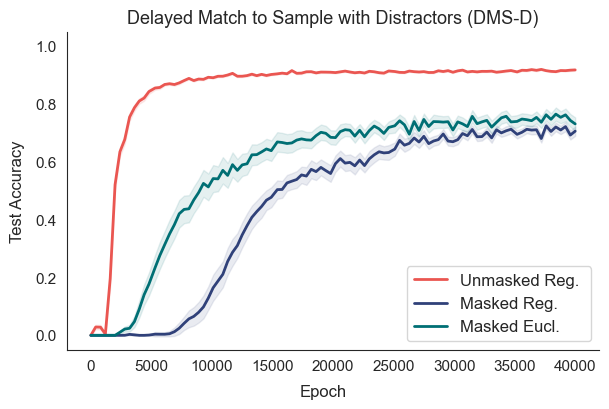

In [62]:
size_scale = 2.0
font_size = int(6 * size_scale)
set_font_size(font_size)
n_fig_columns = min(3, n_tasks)
n_fig_rows = int(np.ceil(n_tasks / n_fig_columns))
fig_size_w = 3 * n_fig_columns * size_scale
fig_size_h = 2 * n_fig_rows * size_scale

fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                       squeeze=True, sharex=True, sharey=True)

for model_idx in range(n_models):
    res = results[model_idx]
    if res is None:
        continue

    this = model_params.iloc[model_idx]
    task_index = this.task_index
    kernel_index = this.kernel_index
    ax = fig.axes[task_index]

    epochs = np.array(res['sampled_epochs'])
    n_runs = res['n_runs']
    acc = np.zeros((n_runs, len(epochs)))

    for ri, run in enumerate(res['runs']):
        for ei, ep in enumerate(epochs):
            acc[ri, ei] = run['epochs'][ep]['accuracy']

    acc_mean = acc.mean(axis=0)
    acc_se = acc.std(axis=0) / np.sqrt(n_runs)

    ax.plot(epochs, acc_mean, color=color_palette[kernel_index],
            label=this.kernel_label, linewidth=2)
    ax.fill_between(epochs, acc_mean - 1.96 * acc_se, acc_mean + 1.96 * acc_se,
                     color=color_palette[kernel_index], alpha=0.1)
    ax.set_title(this.task_label)

fig.axes[0].set_ylim((-0.05, 1.05))
# legend on first subplot only, deduplicated
handles, labels = fig.axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
fig.text(0.0, 0.5, 'Test Accuracy', ha='center', va='center', rotation='vertical')
sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
fig.tight_layout()

if save_figs:
    fig.savefig(os.path.join(outdir, 'trajectory_accuracy.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

# Weight-kernel similarity over training

# Loss components over training

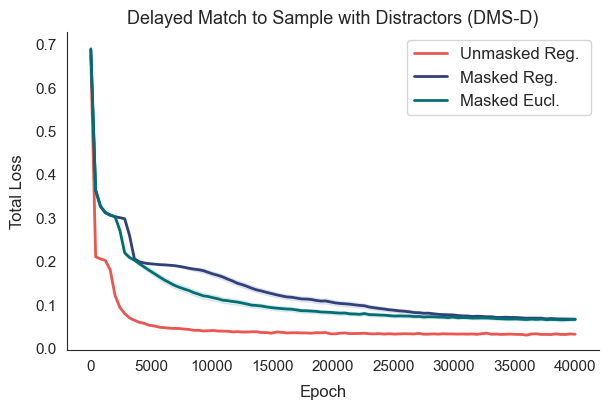

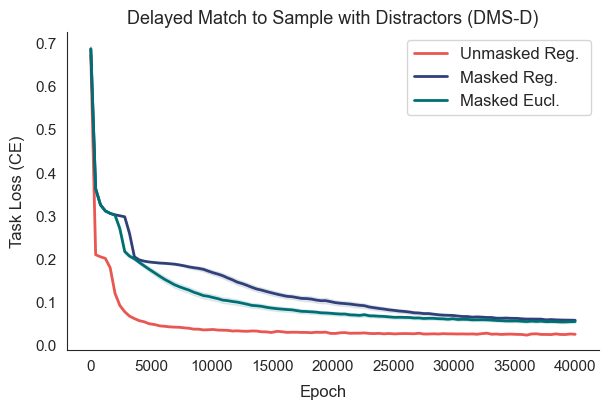

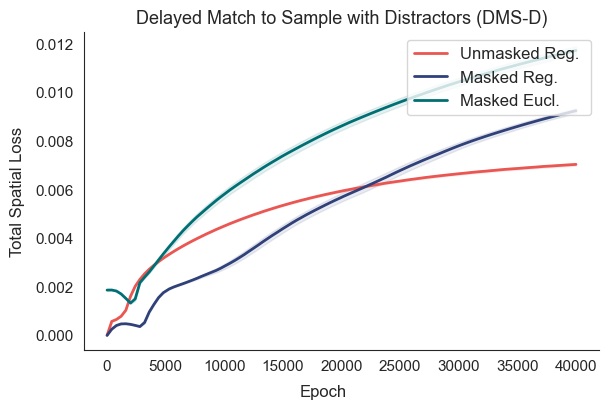

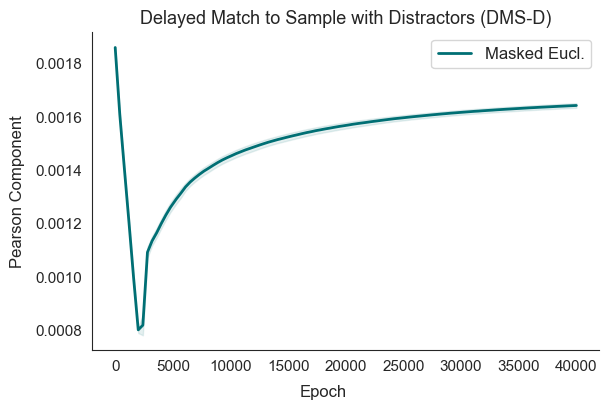

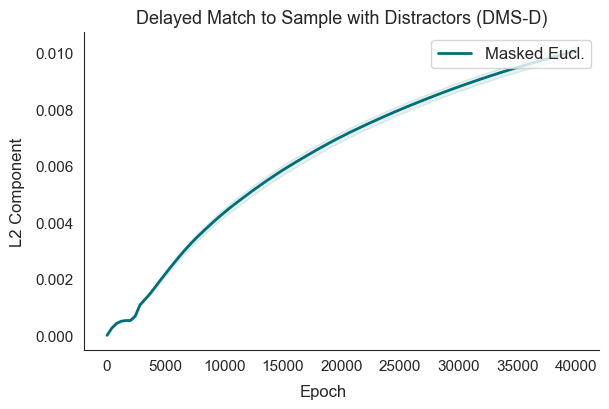

In [63]:
loss_metrics = [
    {'key': 'total_loss',         'ylabel': 'Total Loss',           'file_suff': 'total_loss'},
    {'key': 'task_loss',          'ylabel': 'Task Loss (CE)',       'file_suff': 'task_loss'},
    {'key': 'total_spatial_loss', 'ylabel': 'Total Spatial Loss',   'file_suff': 'spatial_loss'},
    {'key': 'pearson_component',  'ylabel': 'Pearson Component',    'file_suff': 'pearson_component'},
    {'key': 'l2_component',       'ylabel': 'L2 Component',         'file_suff': 'l2_component'},
]

for lm in loss_metrics:
    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    any_plotted = False

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']
        vals = np.full((n_runs, len(epochs)), np.nan)

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                losses = run['epochs'][ep].get('losses')
                if losses is not None:
                    v = losses.get(lm['key'])
                    if v is not None:
                        vals[ri, ei] = v

        if np.all(np.isnan(vals)):
            continue

        any_plotted = True
        vals_mean = np.nanmean(vals, axis=0)
        vals_se = np.nanstd(vals, axis=0) / np.sqrt(n_runs)

        ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.fill_between(epochs, vals_mean - 1.96 * vals_se, vals_mean + 1.96 * vals_se,
                         color=color_palette[kernel_index], alpha=0.1)
        ax.set_title(this.task_label)

    if not any_plotted:
        plt.close(fig)
        continue

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='upper right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, lm['ylabel'], ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_{lm["file_suff"]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

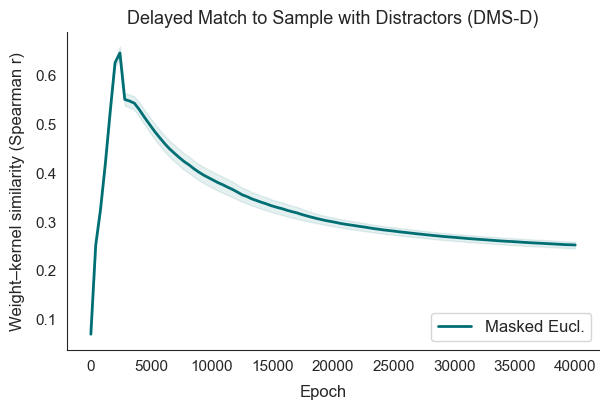

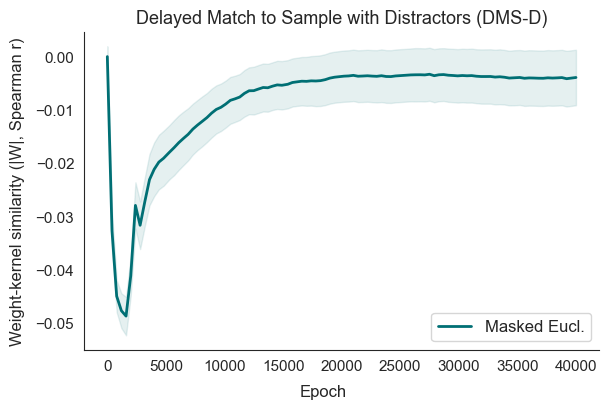

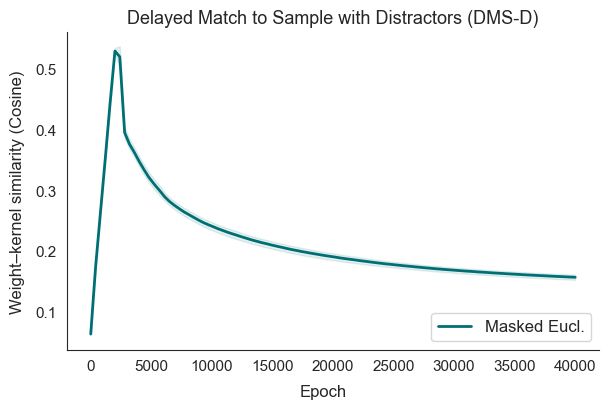

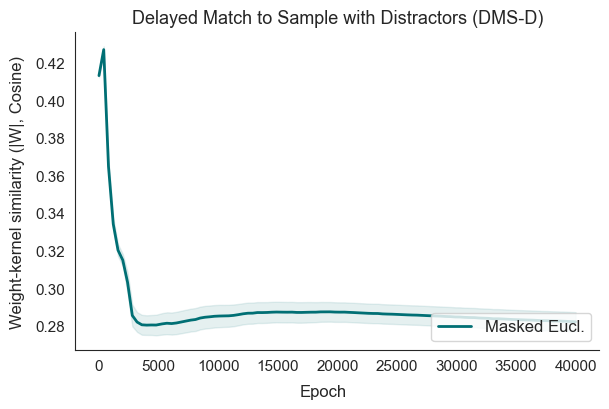

In [64]:
similarity_metrics = {
    'spearman': 'Weight–kernel similarity (Spearman r)',
    'spearman_abs': 'Weight-kernel similarity (|W|, Spearman r)',
    'cosine': 'Weight–kernel similarity (Cosine)',
    'cosine_abs': 'Weight-kernel similarity (|W|, Cosine)',
}

for metric_key, metric_label in similarity_metrics.items():

    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        # skip models without spatial kernel
        if res['runs'][0]['epochs'][res['sampled_epochs'][0]]['weight_kernel_similarity'] is None:
            continue

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']
        vals = np.zeros((n_runs, len(epochs)))

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                vals[ri, ei] = run['epochs'][ep]['weight_kernel_similarity'][metric_key]

        vals_mean = vals.mean(axis=0)
        vals_se = vals.std(axis=0) / np.sqrt(n_runs)

        ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.fill_between(epochs, vals_mean - 1.96 * vals_se, vals_mean + 1.96 * vals_se,
                         color=color_palette[kernel_index], alpha=0.1)
        ax.set_title(this.task_label)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, metric_label, ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_wk_{metric_key}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

# fMRI variance explained over training

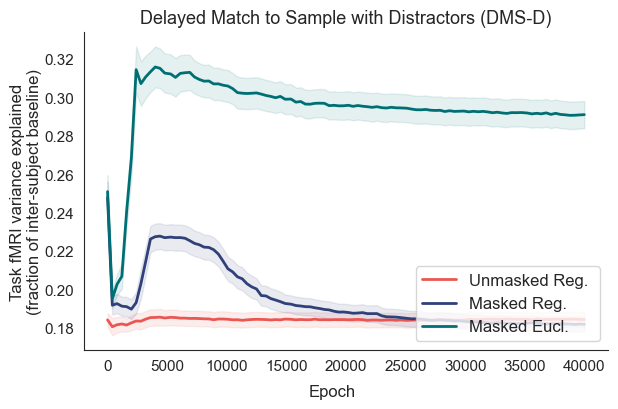

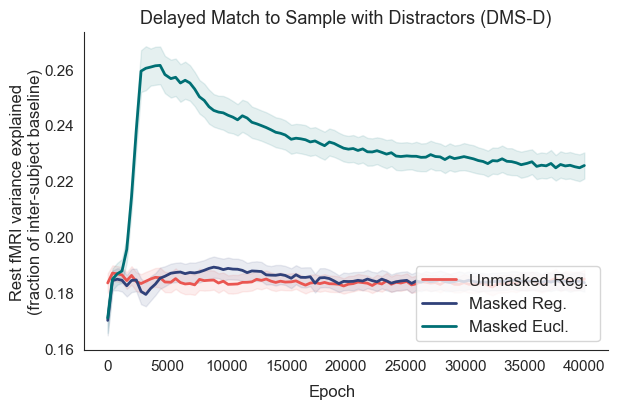

In [65]:
fmri_ve_metrics = [
    {
        'key': 'fmri_task_ve',
        'baseline': fmri_baselines['task'],
        'ylabel': 'Task fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': 'fmri_task_ve',
    },
    {
        'key': 'fmri_rest_ve',
        'baseline': fmri_baselines['rest'],
        'ylabel': 'Rest fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': 'fmri_rest_ve',
    },
]

for vm in fmri_ve_metrics:
    if vm['baseline'] is None:
        print(f'Skipping {vm["key"]} (no fMRI data)')
        continue

    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue
        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']
        vals = np.zeros((n_runs, len(epochs)))

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                ve_arr = run['epochs'][ep][vm['key']]
                if ve_arr is None:
                    vals[ri, ei] = np.nan
                else:
                    # sum across PCs, mean across subjects, normalize by baseline
                    vals[ri, ei] = ve_arr.sum(axis=0).mean() / vm['baseline']

        vals_mean = np.nanmean(vals, axis=0)
        vals_se = np.nanstd(vals, axis=0) / np.sqrt(n_runs)

        ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.fill_between(epochs, vals_mean - 1.96 * vals_se, vals_mean + 1.96 * vals_se,
                         color=color_palette[kernel_index], alpha=0.1)
        ax.set_title(this.task_label)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, vm['ylabel'], ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_{vm["file_suff"]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

# fMRI variance explained by node subset

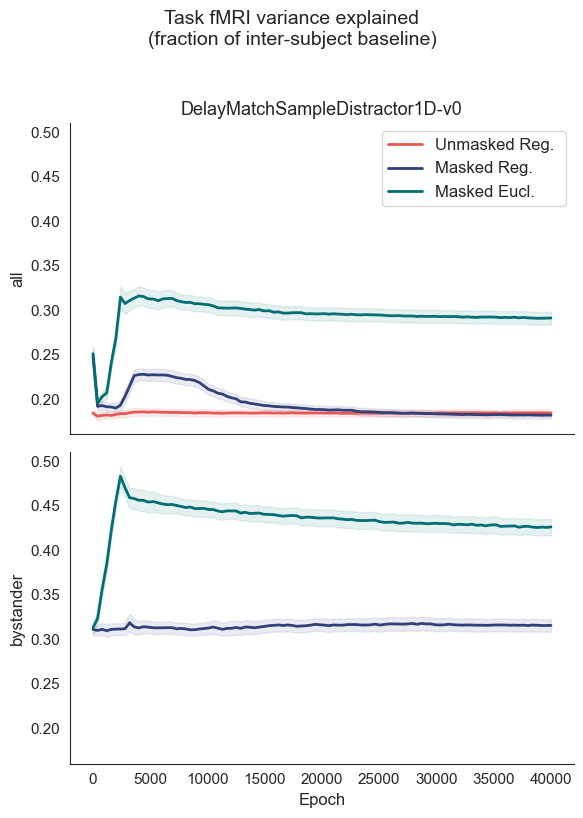

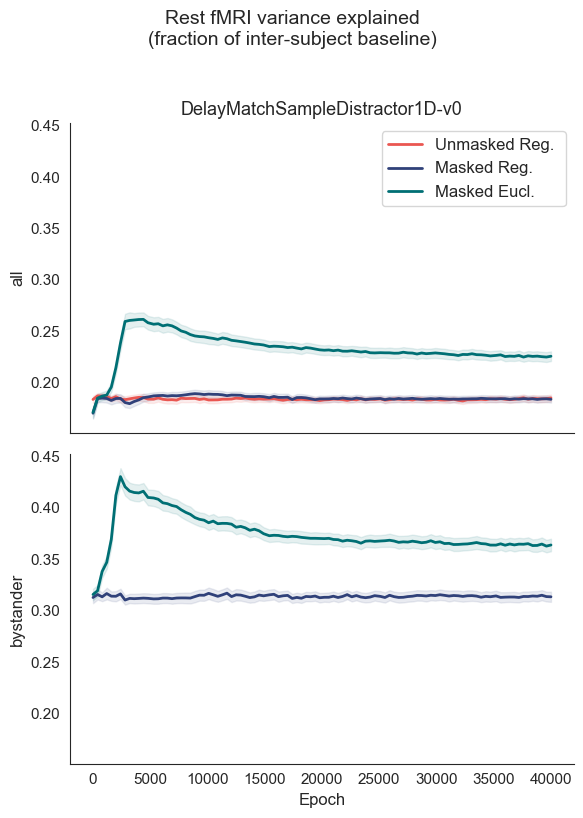

In [66]:
# fMRI VE over training, broken down by node subset
# Rows = node subsets, columns = tasks, colors = kernel types
# Uses node_subsets data when available, falls back to top-level keys for 'all'

if len(subset_names) <= 1:
    print('Only "all" subset available — skipping node subset comparison.')
else:
    subset_linestyles = {
        'all': '-',
        'no_input': '--',
        'no_output': '-.',
        'no_bystander': ':',
    }

    for vm in fmri_ve_metrics:
        if vm['baseline'] is None:
            print(f'Skipping {vm["key"]} (no fMRI data)')
            continue

        n_subset_rows = len(subset_names)
        size_scale = 2.0
        font_size = int(6 * size_scale)
        set_font_size(font_size)
        fig, axes = plt.subplots(
            n_subset_rows, n_fig_columns,
            figsize=(3 * n_fig_columns * size_scale, 2 * n_subset_rows * size_scale),
            squeeze=False, sharex=True, sharey=True)

        for model_idx in range(n_models):
            res = results[model_idx]
            if res is None:
                continue

            this = model_params.iloc[model_idx]
            task_index = this.task_index
            kernel_index = this.kernel_index

            epochs = np.array(res['sampled_epochs'])
            n_runs = res['n_runs']

            for si, sname in enumerate(subset_names):
                ax = axes[si, task_index]
                vals = np.full((n_runs, len(epochs)), np.nan)

                for ri, run in enumerate(res['runs']):
                    for ei, ep in enumerate(epochs):
                        ep_data = run['epochs'][ep]
                        # try node_subsets dict first, fall back to top-level
                        ns = ep_data.get('node_subsets')
                        if ns is not None and sname in ns:
                            ve_arr = ns[sname].get(vm['key'])
                        elif sname == 'all':
                            ve_arr = ep_data.get(vm['key'])
                        else:
                            ve_arr = None
                        if ve_arr is not None:
                            vals[ri, ei] = ve_arr.sum(axis=0).mean() / vm['baseline']

                if np.all(np.isnan(vals)):
                    continue

                vals_mean = np.nanmean(vals, axis=0)
                vals_se = np.nanstd(vals, axis=0) / np.sqrt(n_runs)

                ls = subset_linestyles.get(sname, '-')
                ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                        linestyle=ls, label=this.kernel_label, linewidth=2)
                ax.fill_between(epochs, vals_mean - 1.96 * vals_se,
                                vals_mean + 1.96 * vals_se,
                                color=color_palette[kernel_index], alpha=0.1)

        # labels and formatting
        for si, sname in enumerate(subset_names):
            axes[si, 0].set_ylabel(sname)
            for col in range(n_fig_columns):
                if si == 0 and col < n_tasks:
                    axes[si, col].set_title(task_names[col])

        for col in range(n_fig_columns):
            axes[-1, col].set_xlabel('Epoch')

        # legend on first subplot
        handles, labels = axes[0, 0].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axes[0, 0].legend(by_label.values(), by_label.keys(), loc='upper right')

        fig.suptitle(vm['ylabel'], y=1.02)
        sns.despine(fig=fig, offset=0, trim=False,
                    left=False, right=True, top=True, bottom=False)
        fig.tight_layout()

        if save_figs:
            fig.savefig(os.path.join(outdir, f'trajectory_{vm["file_suff"]}_by_subset.svg'),
                        dpi=300, bbox_inches='tight', pad_inches=0.01)
        plt.show()

# Correlation between weight-kernel similarity and fMRI VE over training

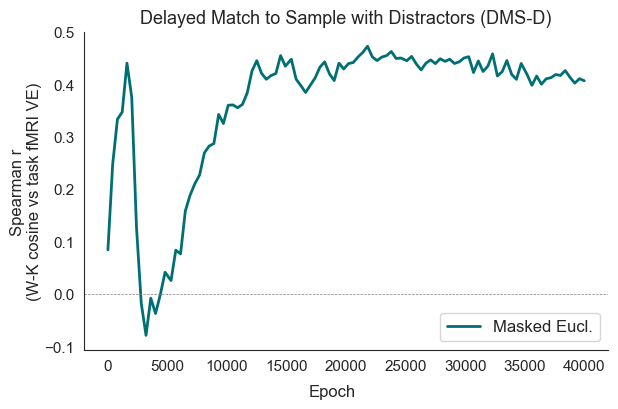

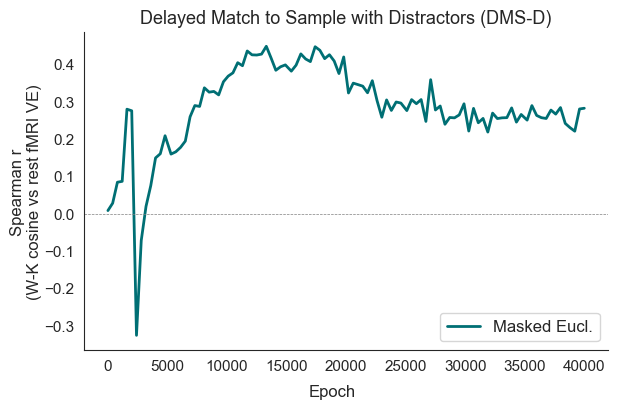

In [67]:
# At each epoch, correlate weight-kernel similarity (cosine) with fMRI VE across
# runs within each kernel type. Plot the Spearman r trajectory over training.

wk_metric = 'cosine'

fmri_ve_corr_metrics = [
    {
        'key': 'fmri_task_ve',
        'baseline': fmri_baselines['task'],
        'ylabel': f'Spearman r\n(W-K {wk_metric} vs task fMRI VE)',
        'file_suff': f'corr_wk_{wk_metric}_vs_fmri_task_ve',
    },
    {
        'key': 'fmri_rest_ve',
        'baseline': fmri_baselines['rest'],
        'ylabel': f'Spearman r\n(W-K {wk_metric} vs rest fMRI VE)',
        'file_suff': f'corr_wk_{wk_metric}_vs_fmri_rest_ve',
    },
]

for vm in fmri_ve_corr_metrics:
    if vm['baseline'] is None:
        print(f'Skipping {vm["key"]} (no fMRI data)')
        continue

    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        # skip models without spatial kernel
        ep0 = res['sampled_epochs'][0]
        if res['runs'][0]['epochs'][ep0]['weight_kernel_similarity'] is None:
            continue

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']

        # extract per-run arrays: (n_runs, n_epochs)
        wk_vals = np.zeros((n_runs, len(epochs)))
        ve_vals = np.full((n_runs, len(epochs)), np.nan)

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                ep_data = run['epochs'][ep]
                wk_vals[ri, ei] = ep_data['weight_kernel_similarity'][wk_metric]
                ve_arr = ep_data[vm['key']]
                if ve_arr is not None:
                    ve_vals[ri, ei] = ve_arr.sum(axis=0).mean() / vm['baseline']

        # at each epoch, correlate across runs
        corr_per_epoch = np.full(len(epochs), np.nan)
        for ei in range(len(epochs)):
            wk_col = wk_vals[:, ei]
            ve_col = ve_vals[:, ei]
            valid = ~np.isnan(wk_col) & ~np.isnan(ve_col)
            if valid.sum() > 3:
                r, _ = stats.spearmanr(wk_col[valid], ve_col[valid])
                corr_per_epoch[ei] = r

        ax.plot(epochs, corr_per_epoch, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.set_title(this.task_label)

    # reference line at r=0
    for ax in fig.axes[:n_tasks]:
        ax.axhline(y=0, color=[0.5]*3, linestyle='--', linewidth=0.5)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, vm['ylabel'], ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_{vm["file_suff"]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

# Combined panel: accuracy, similarity, fMRI VE

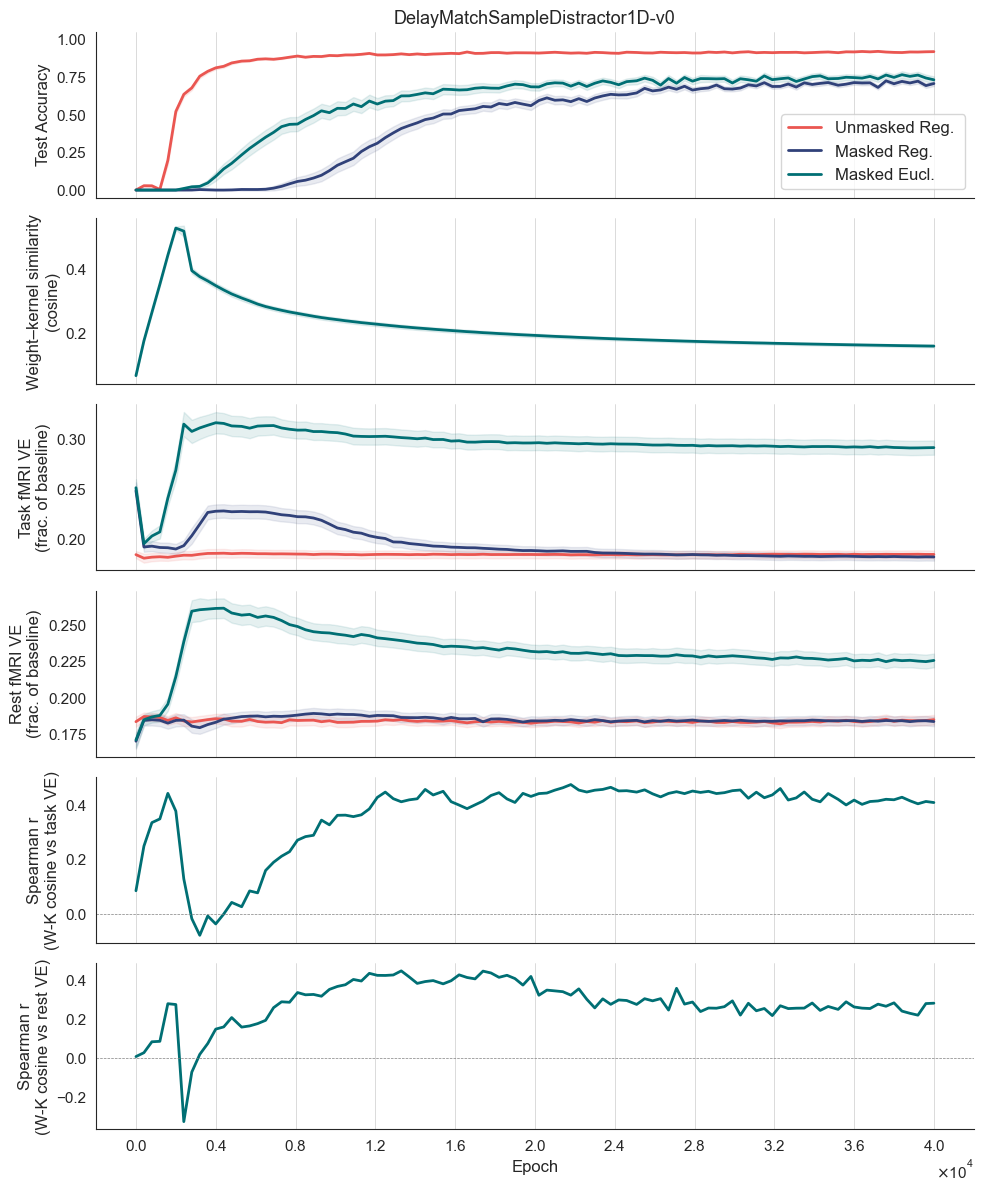

In [68]:
# Combined panel: accuracy, similarity, task fMRI VE, rest fMRI VE,
# corr(W-K cosine vs task VE), corr(W-K cosine vs rest VE)
# Columns = tasks, rows = metrics

has_fmri = fmri_baselines['task'] is not None
wk_metric_mean = 'cosine'   # for the mean trajectory row
wk_metric_corr = 'cosine'     # for the across-run correlation rows

# define rows
row_defs = [
    {'type': 'mean',  'key': 'accuracy',              'label': 'Test Accuracy'},
    {'type': 'mean',  'key': f'wk_{wk_metric_mean}',  'label': f'Weight–kernel similarity\n({wk_metric_mean})'},
]
if has_fmri:
    row_defs += [
        {'type': 'mean',  'key': 'fmri_task_ve',  'label': 'Task fMRI VE\n(frac. of baseline)'},
        {'type': 'mean',  'key': 'fmri_rest_ve',  'label': 'Rest fMRI VE\n(frac. of baseline)'},
        {'type': 'corr',  'key': 'fmri_task_ve',  'label': f'Spearman r\n(W-K {wk_metric_corr} vs task VE)'},
        {'type': 'corr',  'key': 'fmri_rest_ve',  'label': f'Spearman r\n(W-K {wk_metric_corr} vs rest VE)'},
    ]

n_metric_rows = len(row_defs)

size_scale = 2.0
font_size = int(6 * size_scale)
set_font_size(font_size)
fig_w = 5 * n_fig_columns * size_scale
fig_h = 1 * n_metric_rows * size_scale

fig, axes = plt.subplots(n_metric_rows, n_fig_columns,
                          figsize=(fig_w, fig_h),
                          squeeze=False, sharex=True, sharey='row')

# --- Pre-extract all per-run data ---
# Store {model_idx: {metric: array(n_runs, n_epochs)}}
model_data = {}
for model_idx in range(n_models):
    res = results[model_idx]
    if res is None:
        continue
    this = model_params.iloc[model_idx]
    epochs = np.array(res['sampled_epochs'])
    n_runs = res['n_runs']
    has_wk = res['runs'][0]['epochs'][epochs[0]]['weight_kernel_similarity'] is not None

    d = {'epochs': epochs, 'n_runs': n_runs, 'has_wk': has_wk}
    d['accuracy'] = np.zeros((n_runs, len(epochs)))
    d[f'wk_{wk_metric_mean}'] = np.full((n_runs, len(epochs)), np.nan)
    d[f'wk_{wk_metric_corr}'] = np.full((n_runs, len(epochs)), np.nan)
    d['fmri_task_ve'] = np.full((n_runs, len(epochs)), np.nan)
    d['fmri_rest_ve'] = np.full((n_runs, len(epochs)), np.nan)

    for ri, run in enumerate(res['runs']):
        for ei, ep in enumerate(epochs):
            ep_data = run['epochs'][ep]
            d['accuracy'][ri, ei] = ep_data['accuracy']
            if has_wk:
                d[f'wk_{wk_metric_mean}'][ri, ei] = ep_data['weight_kernel_similarity'][wk_metric_mean]
                d[f'wk_{wk_metric_corr}'][ri, ei] = ep_data['weight_kernel_similarity'][wk_metric_corr]
            if has_fmri:
                ve_task = ep_data.get('fmri_task_ve')
                ve_rest = ep_data.get('fmri_rest_ve')
                if ve_task is not None:
                    d['fmri_task_ve'][ri, ei] = ve_task.sum(axis=0).mean() / fmri_baselines['task']
                if ve_rest is not None:
                    d['fmri_rest_ve'][ri, ei] = ve_rest.sum(axis=0).mean() / fmri_baselines['rest']

    model_data[model_idx] = d

# --- Plot each row ---
for row_idx, rdef in enumerate(row_defs):

    if rdef['type'] == 'mean':
        # line + CI of the metric mean across runs
        for model_idx in range(n_models):
            if model_idx not in model_data:
                continue
            d = model_data[model_idx]
            this = model_params.iloc[model_idx]
            ax = axes[row_idx, this.task_index]
            vals = d[rdef['key']]
            if np.all(np.isnan(vals)):
                continue
            m = np.nanmean(vals, axis=0)
            se = np.nanstd(vals, axis=0) / np.sqrt(d['n_runs'])
            ax.plot(d['epochs'], m, color=color_palette[this.kernel_index],
                    label=this.kernel_label, linewidth=2)
            ax.fill_between(d['epochs'], m - 1.96 * se, m + 1.96 * se,
                             color=color_palette[this.kernel_index], alpha=0.1)

    elif rdef['type'] == 'corr':
        # per-epoch Spearman r between W-K cosine and fMRI VE across runs
        for model_idx in range(n_models):
            if model_idx not in model_data:
                continue
            d = model_data[model_idx]
            this = model_params.iloc[model_idx]
            if not d['has_wk']:
                continue
            ax = axes[row_idx, this.task_index]
            epochs = d['epochs']
            wk = d[f'wk_{wk_metric_corr}']
            ve = d[rdef['key']]

            corr_per_epoch = np.full(len(epochs), np.nan)
            for ei in range(len(epochs)):
                valid = ~np.isnan(wk[:, ei]) & ~np.isnan(ve[:, ei])
                if valid.sum() > 3:
                    r, _ = stats.spearmanr(wk[valid, ei], ve[valid, ei])
                    corr_per_epoch[ei] = r

            ax.plot(epochs, corr_per_epoch, color=color_palette[this.kernel_index],
                    label=this.kernel_label, linewidth=2)

        # reference line at r=0
        for col in range(n_fig_columns):
            axes[row_idx, col].axhline(y=0, color=[0.5]*3, linestyle='--', linewidth=0.5)

# --- Formatting ---
for col in range(n_fig_columns):
    if col < n_tasks:
        axes[0, col].set_title(task_names[col])
    axes[-1, col].set_xlabel('Epoch')

for row_idx, rdef in enumerate(row_defs):
    axes[row_idx, 0].set_ylabel(rdef['label'])

axes[0, 0].set_ylim((-0.05, 1.05))

handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0, 0].legend(by_label.values(), by_label.keys(), loc='lower right')

for row_idx in range(n_metric_rows):
    for col in range(n_fig_columns):
        ax = axes[row_idx, col]
        xl = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 11)
        xl = np.linspace(epochs[0], epochs[-1], 11)
        ax.set_xticks(xl)
        ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.5)

sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
fig.tight_layout()

plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
plt.minorticks_on()

if save_figs:
    fig.savefig(os.path.join(outdir, 'trajectory_combined_panel.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

# Joint trajectory: weight-kernel similarity vs fMRI VE

In [69]:
# ============================================================================
# Joint-trajectory ("hysteresis") fMRI-VE normalization switch
# ============================================================================
# 'baseline' : VE as a fraction of the inter-subject baseline
# 'zscore'   : group-level z of VE vs a random n_pc-dim subspace null.
# Nulls AND baselines are REGION-MATCHED: bystander VE is normalized against a
# null / baseline computed only over the bystander parcels.
ve_normalization = 'zscore'        # 'baseline' or 'zscore'
n_null_subspaces = 1000            # random subspaces for the z-score null
recompute_ve_null = False          # set True to force the null to recompute
ve_sig_alpha = 0.05                # one-sided significance level for the threshold line

ve_unit_label = ('z vs random-subspace null' if ve_normalization == 'zscore'
                 else 'frac. of baseline')
ve_file_tag = '_zscore' if ve_normalization == 'zscore' else ''
region_titles = {'full': 'full network', 'bystander': 'bystanders only'}

def _load_fmri_ts_for_null(n_fmri_subj, hidden_size=100):
    """Load task/rest fMRI for the VE null via the shared loader (src.fmri_io),
    so the null aligns column-for-column with the stored per-subject VE arrays.
    Returns {'task': ts, 'rest': ts}, each (n_timepoints, n_nodes, n_subj)."""
    datadir, _, fmridir = get_paths(model_params_name)
    fmri_task_ts, fmri_rest_ts, _, _ = load_fmri_data(
        datadir, fmridir, n_fmri_subj, hidden_size=hidden_size)
    return {'task': fmri_task_ts, 'rest': fmri_rest_ts}


def _compute_ve_null(fmri_ts_by_mod, n_pc, n_null, seed=0, node_idx=None):
    """Null distribution of the ACROSS-SUBJECT MEAN fraction of fMRI variance
    captured by a random n_pc-dim subspace. If node_idx is given, the fMRI is
    restricted to those parcels first (region-matched null). Centering matches
    pca_projection(centering_mean='data')."""
    rng = np.random.default_rng(seed)
    out = {}
    for mod, ts in fmri_ts_by_mod.items():
        if node_idx is not None:
            ts = ts[:, node_idx, :]
        n_nodes, n_subj = ts.shape[1], ts.shape[2]
        B = np.zeros((n_null, n_nodes, n_pc))               # shared across subjects
        for ni in range(n_null):
            Q, _ = np.linalg.qr(rng.standard_normal((n_nodes, n_pc)))
            B[ni] = Q[:, :n_pc]
        samp = np.zeros((n_subj, n_null))
        for si in range(n_subj):
            Xc = ts[:, :, si] - ts[:, :, si].mean(axis=0, keepdims=True)
            total = float((Xc ** 2).sum())
            if total <= 0.0:
                continue
            proj = np.tensordot(Xc, B, axes=([1], [1]))     # (T, n_null, n_pc)
            samp[si] = (proj ** 2).sum(axis=(0, 2)) / total
        group_null = samp.mean(axis=0)                       # (n_null,)
        g_mean = float(group_null.mean())
        g_sd = float(group_null.std(ddof=1))
        out[mod] = {'group_mean': g_mean, 'group_sd': g_sd,
                    'group_null_z': (group_null - g_mean) / g_sd}   # standardized
    return out


def _bystander_idx_of(model_idx):
    """Bystander parcel indices for a model (from the pickle), or None."""
    res = results[model_idx]
    by = (res or {}).get('node_subsets', {}).get('bystander') if res else None
    return np.asarray(by, dtype=int) if by else None


def _ve_arr_for(ed, region, key):
    """Per-epoch VE array for a region: 'full' (top-level) or 'bystander'."""
    if region == 'bystander':
        return ed.get('node_subsets', {}).get('bystander', {}).get(key)
    return ed.get(key)


def _topo_for(ed, region):
    """Per-epoch topology dict for a region ('full' or 'bystander')."""
    return ed.get('topology_bystander') if region == 'bystander' else ed.get('topology')


# Region-matched inter-subject baselines for the 'baseline' mode. The full
# baseline is the global fmri_baselines; bystander baselines come from the pickle
# (per model), keyed by the bystander parcel set.
ve_baseline_bystander = {}
for _res in results:
    if _res is None:
        continue
    _by = _res.get('node_subsets', {}).get('bystander')
    _bbl = _res.get('fmri_intersubj_baselines_bystander')
    if _by and _bbl is not None:
        ve_baseline_bystander[tuple(int(i) for i in _by)] = _bbl

_has_bystander = any((_bystander_idx_of(i) is not None and _bystander_idx_of(i).size > 2)
                     for i in range(n_models))
ve_regions = ['full', 'bystander'] if _has_bystander else ['full']

if ve_normalization == 'zscore' and (recompute_ve_null or 've_null' not in globals()
                                     or 'full' not in ve_null):
    _sample_ve = None
    for _res in results:
        if _res is None:
            continue
        _cand = _res['runs'][0]['epochs'][_res['sampled_epochs'][0]].get('fmri_task_ve')
        if _cand is not None:
            _sample_ve = _cand
            break
    if _sample_ve is None:
        raise RuntimeError('No fMRI VE arrays found; cannot build the z-score null.')
    _n_pc, _n_fmri_subj = _sample_ve.shape
    print(f'Building random-subspace VE null (full + bystander): n_pc={_n_pc}, '
          f'n_fmri_subj={_n_fmri_subj}, n_null={n_null_subspaces} ...')
    _fmri_ts = _load_fmri_ts_for_null(_n_fmri_subj)
    ve_null = {'full': _compute_ve_null(_fmri_ts, _n_pc, n_null_subspaces),
               'bystander': {}}
    for _i in range(n_models):
        _bi = _bystander_idx_of(_i)
        if _bi is None or _bi.size <= 2:
            continue
        _bkey = tuple(int(x) for x in _bi)
        if _bkey not in ve_null['bystander']:
            ve_null['bystander'][_bkey] = _compute_ve_null(
                _fmri_ts, _n_pc, n_null_subspaces, node_idx=_bi)
    print(f"  full null group-mean VE: task={ve_null['full']['task']['group_mean']:.3f}, "
          f"rest={ve_null['full']['rest']['group_mean']:.3f}")
    print(f"  bystander null parcel-sets: {len(ve_null['bystander'])}")


def _region_null(region, bystander_idx):
    if region == 'bystander':
        return ve_null['bystander'][tuple(int(i) for i in bystander_idx)]
    return ve_null['full']


def ve_sig_threshold_for(region='full', bystander_idx=None):
    """Shared (pooled-modality) empirical (1-alpha) z threshold for a region."""
    z = _region_null(region, bystander_idx)
    pooled = np.concatenate([z[m]['group_null_z'] for m in ('task', 'rest')])
    return float(np.nanpercentile(pooled, 100 * (1 - ve_sig_alpha)))


if ve_normalization == 'zscore':
    ve_sig_threshold = ve_sig_threshold_for('full')   # scalar, used by full-only plots
    print(f'z-significance threshold (full, one-sided p<{ve_sig_alpha:g}): '
          f'{ve_sig_threshold:.3f}')


def joint_ve_value(ve_arr, modality, region='full', bystander_idx=None):
    """Per-(run, epoch) scalar fMRI VE, honoring ve_normalization and the
    region-matched null / baseline. region in {'full', 'bystander'}."""
    group_ve = float(ve_arr.sum(axis=0).mean())          # across-subject mean total VE
    if ve_normalization == 'zscore':
        nm = _region_null(region, bystander_idx)[modality]
        return (group_ve - nm['group_mean']) / nm['group_sd']
    if region == 'bystander':
        bl = ve_baseline_bystander[tuple(int(i) for i in bystander_idx)][modality]
    else:
        bl = fmri_baselines[modality]
    return group_ve / bl


z-significance threshold (full, one-sided p<0.05): 1.782


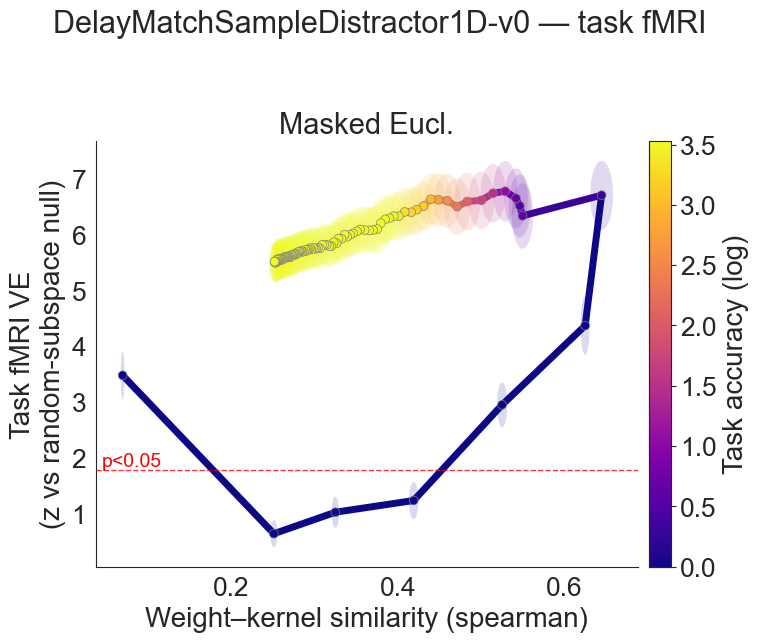

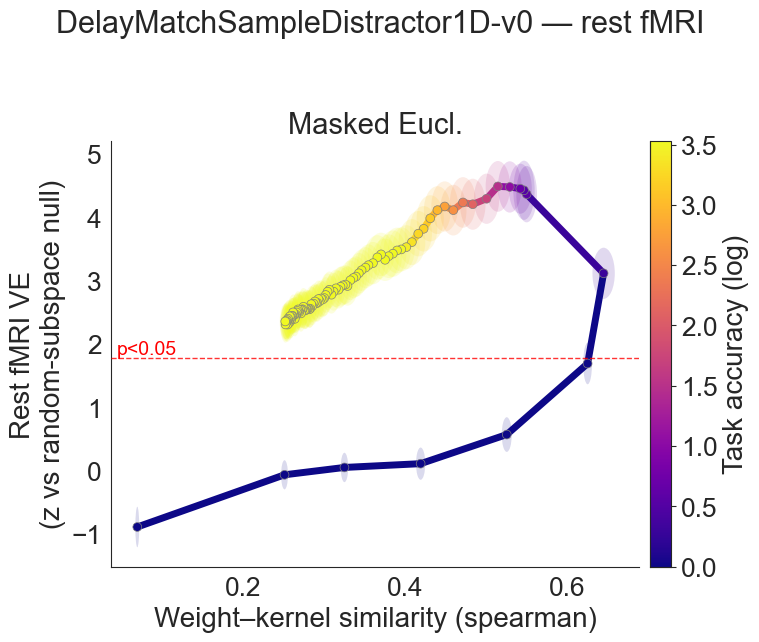

In [81]:
# Scatter: weight-kernel similarity (x) vs fMRI VE (y), color-coded by epoch
# One subplot per (task x kernel), only for models with spatial kernels
# Mean trajectory (thick line) + 95% CI ellipses, individual runs at alpha 0.1

if True:
    
    log_acc = True
    show_runs = False

    if fmri_baselines['task'] is None:
        print('Skipping (no fMRI data)')
    else:
        wk_metric = 'spearman'

        fmri_configs = [
            {'key': 'fmri_task_ve', 'baseline': fmri_baselines['task'],
             'ylabel': f'Task fMRI VE\n({ve_unit_label})', 'suffix': 'task'},
            {'key': 'fmri_rest_ve', 'baseline': fmri_baselines['rest'],
             'ylabel': f'Rest fMRI VE\n({ve_unit_label})', 'suffix': 'rest'},
        ]

        size_scale = 2.0
        font_size = int(10 * size_scale)
        set_font_size(font_size)

        for fc in fmri_configs:
            fmri_key = fc['key']
            fmri_baseline = fc['baseline']

            for task_idx in range(n_tasks):
                # collect models for this task that have spatial kernels
                task_models = []
                for model_idx in range(n_models):
                    res = results[model_idx]
                    if res is None:
                        continue
                    this = model_params.iloc[model_idx]
                    if this.task_index != task_idx:
                        continue
                    ep0 = res['sampled_epochs'][0]
                    if res['runs'][0]['epochs'][ep0]['weight_kernel_similarity'] is None:
                        continue
                    task_models.append((model_idx, this))

                if not task_models:
                    continue

                n_panels = len(task_models)
                fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels * size_scale, 3.2 * size_scale),
                                        squeeze=False, sharey=True)
                axes = axes.ravel()

                for pi, (model_idx, this) in enumerate(task_models):
                    res = results[model_idx]
                    ax = axes[pi]
                    epochs = np.array(res['sampled_epochs'])
                    n_runs = res['n_runs']

                    # colormap: epoch progression
                    if 'GoNogo' in task_names[task_idx]:
                        cmbounds = [0.4, 1]
                    else:
                        cmbounds = [0, 0.33]
                    cmbounds = np.array(cmbounds)
                    if log_acc:
                        cmbounds = np.log1p(cmbounds*100)
                    cmap = cm.plasma
                    norm = plt.Normalize(cmbounds[0], cmbounds[1])

                    # collect all runs into arrays: (n_runs, n_epochs)
                    all_wk = np.full((n_runs, len(epochs)), np.nan)
                    all_ve = np.full((n_runs, len(epochs)), np.nan)
                    all_ac = np.full((n_runs, len(epochs)), np.nan)

                    for ri, run in enumerate(res['runs']):
                        for ei, ep in enumerate(epochs):
                            ep_data = run['epochs'][ep]
                            all_ac[ri, ei] = ep_data['accuracy']
                            all_wk[ri, ei] = ep_data['weight_kernel_similarity'][wk_metric]
                            ve_arr = ep_data[fmri_key]
                            if ve_arr is not None:
                                all_ve[ri, ei] = joint_ve_value(ve_arr, fc['suffix'])
                    if log_acc:
                        all_ac = np.log1p(all_ac*100)

                    # individual run traces at low alpha
                    if show_runs:
                        for ri in range(0, n_runs, 4):
                            for ei in range(len(epochs) - 1):
                                ax.plot(all_wk[ri, ei:ei+2], all_ve[ri, ei:ei+2],
                                        color=cmap(norm(all_ac[ri,ei])), linewidth=0.5, alpha=0.2)
                            ax.scatter(all_wk[ri], all_ve[ri], c=all_ac[ri,:], cmap=cmap, norm=norm,
                                    s=10, alpha=0.01, edgecolors='none', zorder=2)
                    
                    # mean trajectory (thick line) with CI ellipses
                    wk_mean = np.nanmean(all_wk, axis=0)
                    ve_mean = np.nanmean(all_ve, axis=0)
                    ac_mean = np.nanmean(all_ac, axis=0)
                    wk_se = np.nanstd(all_wk, axis=0) / np.sqrt(n_runs)
                    ve_se = np.nanstd(all_ve, axis=0) / np.sqrt(n_runs)
                    ac_se = np.nanstd(all_ac, axis=0) / np.sqrt(n_runs)
                    
                    # plot mean trajectory colored by accuracy
                    for ei in range(len(epochs) - 1):
                        ax.plot(wk_mean[ei:ei+2], ve_mean[ei:ei+2],
                                color=cmap(norm(ac_mean[ei])), linewidth=5, alpha=1.0, zorder=4)
                    ax.scatter(wk_mean, ve_mean, c=ac_mean, cmap=cmap, norm=norm,
                              s=40, alpha=1.0, edgecolors='grey', linewidths=0.5, zorder=5)
                    
                    # CI ellipses at each epoch (horizontal = wk CI, vertical = ve CI), accuracy color
                    for ei in range(len(epochs)):
                        ellipse = plt.matplotlib.patches.Ellipse(
                            (wk_mean[ei], ve_mean[ei]),
                            width=2 * 1.96 * wk_se[ei],
                            height=2 * 1.96 * ve_se[ei],
                            facecolor=cmap(norm(ac_mean[ei])),
                            alpha=0.15,
                            edgecolor='none',
                            zorder=3,
                        )
                        ax.add_patch(ellipse)

                    ax.set_xlabel(f'Weight\u2013kernel similarity ({wk_metric})')
                    if pi == 0:
                        ax.set_ylabel(fc['ylabel'])
                    ax.set_title(this.kernel_label)
                    if ve_normalization == 'zscore':
                        ax.axhline(ve_sig_threshold, color='red', linestyle='--',
                                   linewidth=1, alpha=0.8, zorder=6)
                        ax.text(0.01, ve_sig_threshold, f'p<{ve_sig_alpha:g}',
                                transform=ax.get_yaxis_transform(), va='bottom',
                                ha='left', color='red', fontsize=font_size - 6)

                # colorbar on last axis
                sm = cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=axes[-1], fraction=0.05, pad=0.02)
                cbar.set_label('Task accuracy (log)' if log_acc else 'Task accuracy')

                fig.suptitle(f'{task_names[task_idx]} — {fc["suffix"]} fMRI', y=1.02)
                sns.despine(fig=fig, offset=0, trim=False)
                fig.tight_layout()

                if save_figs:
                    fig.savefig(os.path.join(outdir, f'trajectory_joint_{fc["suffix"]}_{task_names[task_idx]}{ve_file_tag}.svg'),
                                dpi=300, bbox_inches='tight', pad_inches=0.01)
                plt.show()



# Topology across phase III (paper figure)

Bystander-only topology restricted to **phase III** (epochs from the weight–kernel-similarity bend onward, detected per model as the argmax of run-mean W–K cosine). **Row 1:** the four settled metrics — clustering, rich-club (norm), participation, degree trimmed-mean — run-mean ± 95% CI with task accuracy overlaid. **Row 2:** their rates of change (each normalized over phase III), mean ± 95% CI across runs, with CI-excludes-zero segments emphasized and accuracy overlaid.

Spearman r (topology metric vs task accuracy) - DelayMatchSampleDistractor1D-v0 - Unmasked Reg.  - full network - training (n=100):
    Mean degree of top 20% hubs   rho = -0.353   p = 0.000485   change =   -5.9%   (from epoch 2,399)
    Normalized rich-club          rho = -0.704   p = 1.25e-10   change =   -5.0%   (from epoch 14,899)
    Clustering coefficient        rho = +0.924   p = 1.41e-42   change = +291.7%   (from epoch 0)
    Participation coefficient     rho = -0.761   p = 5.14e-19   change =   -2.5%   (from epoch 2,399)
    Conn. length (top 20%, mm)    rho = -0.023   p = 0.821   change =   -0.1%   (from epoch 0)


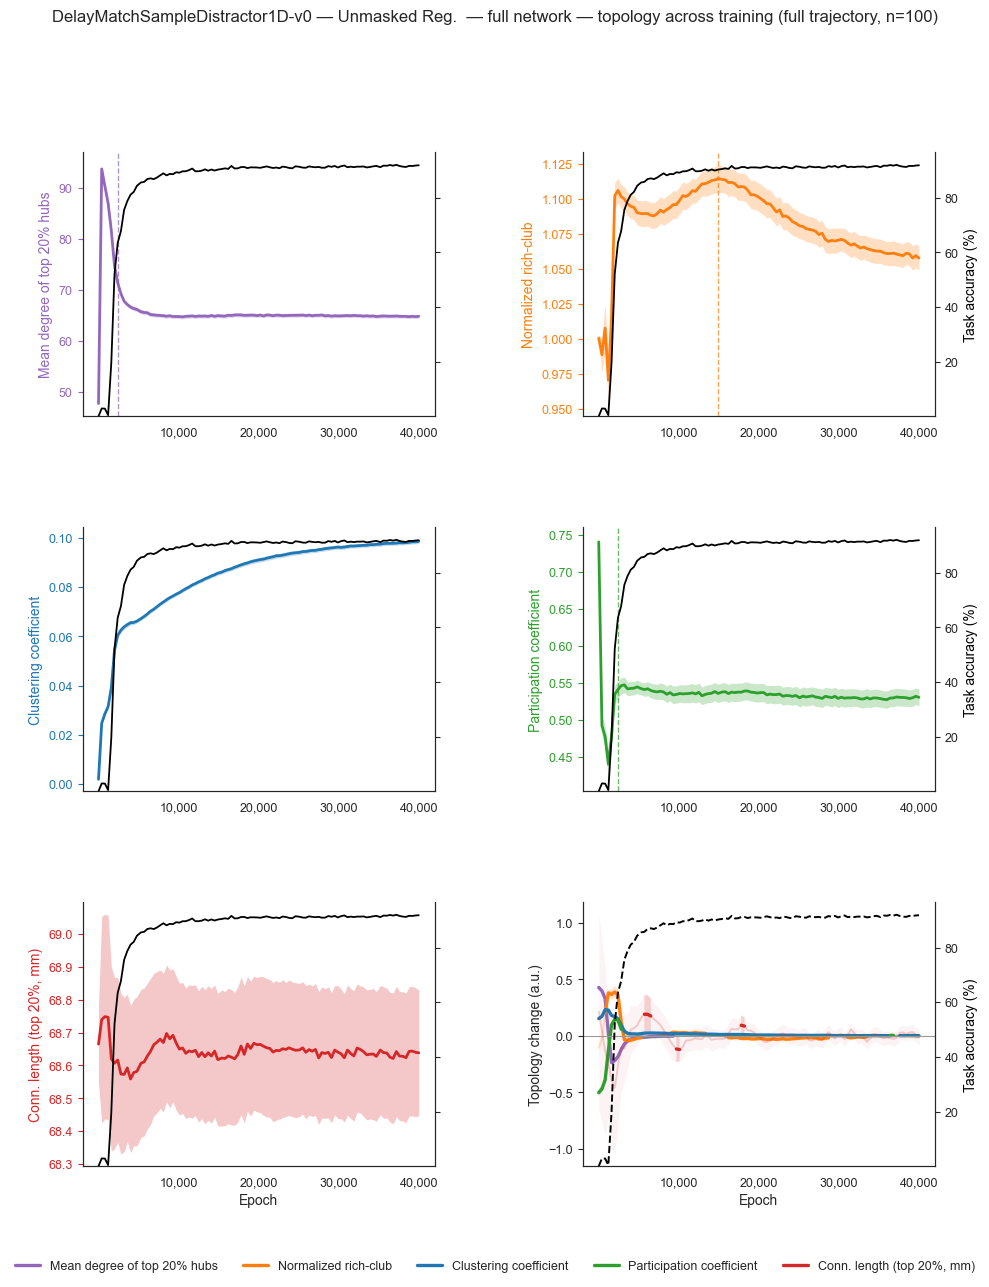

Spearman r (topology metric vs task accuracy) - DelayMatchSampleDistractor1D-v0 - Masked Reg.  - bystanders only - phase III (n=100):
    Mean degree of top 20% hubs   rho = -0.977   p = 1.66e-58   change =  -18.6%   (from epoch 5,299)
    Normalized rich-club          rho = -0.939   p = 5.62e-30   change =  -12.3%   (from epoch 14,899)
    Clustering coefficient        rho = +0.982   p = 1.87e-68   change = +412.9%   (from epoch 2,399)
    Participation coefficient     rho = +0.975   p = 7.95e-54   change =  +79.4%   (from epoch 7,299)
    Conn. length (top 20%, mm)    rho = +0.683   p = 3.51e-14   change =   +0.1%   (from epoch 2,399)


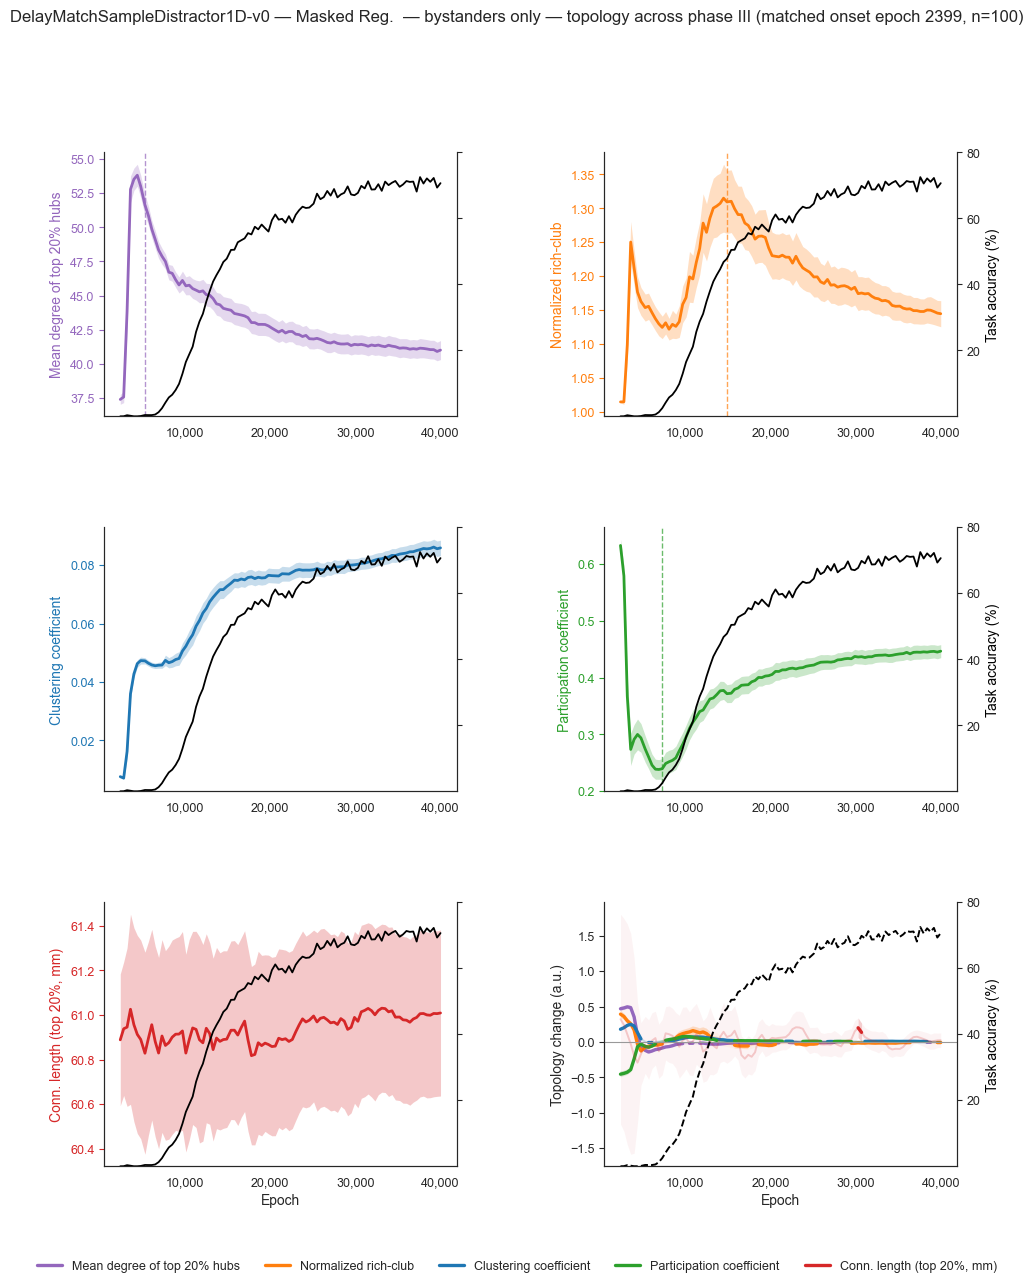

Spearman r (topology metric vs task accuracy) - DelayMatchSampleDistractor1D-v0 - Masked Eucl. - bystanders only - phase III (n=100):
    Mean degree of top 20% hubs   rho = +0.927   p = 6.14e-41   change =  +11.6%   (from epoch 2,399)
    Normalized rich-club          rho = -0.762   p = 1.36e-16   change =   -1.5%   (from epoch 7,699)
    Clustering coefficient        rho = +0.963   p = 5.01e-54   change = +112.1%   (from epoch 2,399)
    Participation coefficient     rho = +0.954   p = 3.69e-47   change =  +40.4%   (from epoch 4,399)
    Conn. length (top 20%, mm)    rho = +0.946   p = 8.13e-47   change =   +3.8%   (from epoch 2,399)


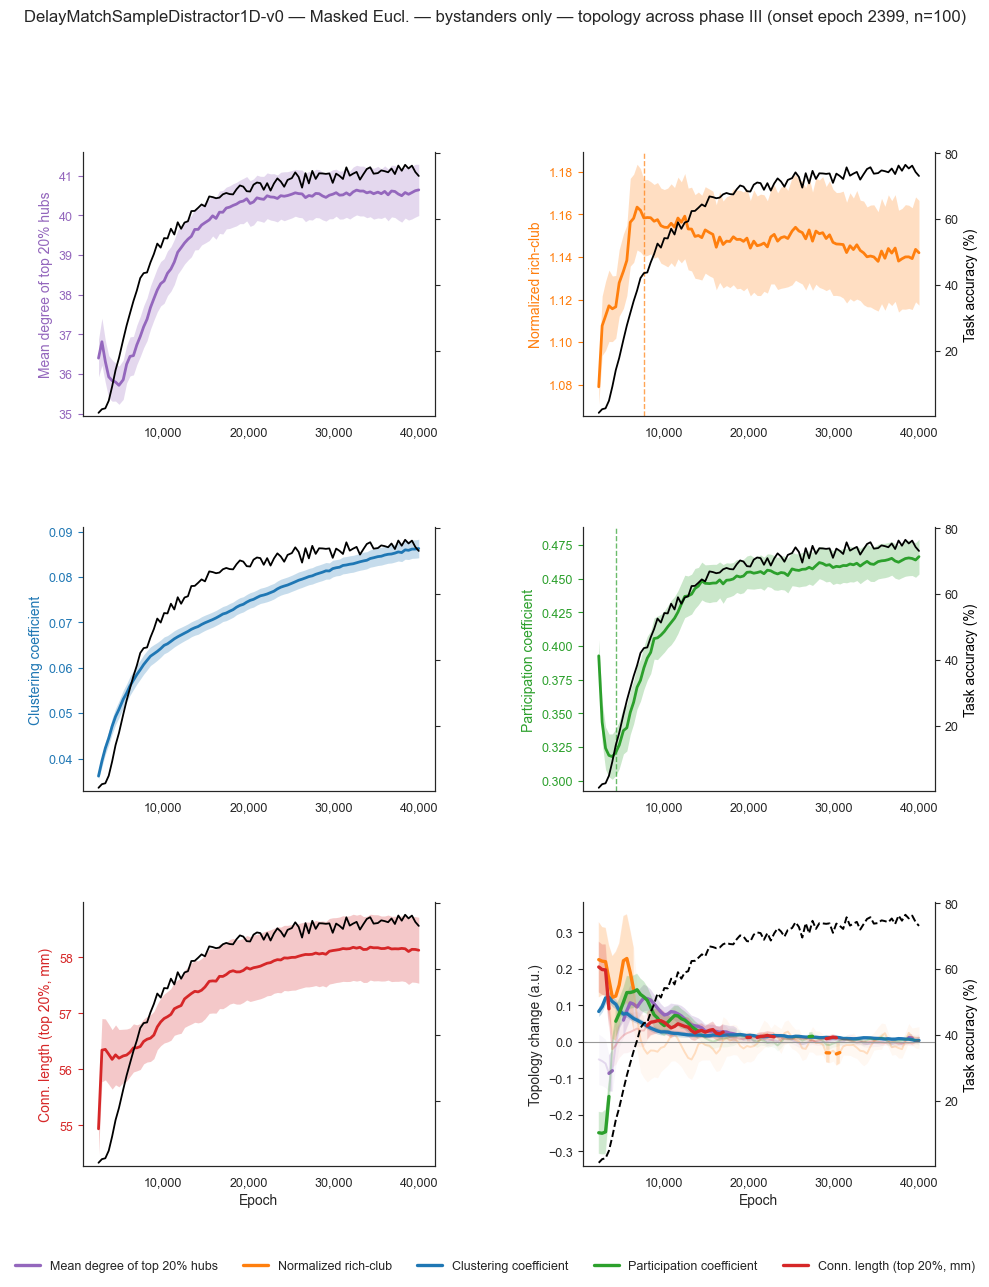

In [89]:
# ============================================================================
# Topology paper figure — one figure per model (bystander/phase-III or full-net)
# ----------------------------------------------------------------------------
# Two-row figure per model:
#   Row 1: the four settled topology metrics (clustering, rich-club,
#          participation, degree trimmed-mean), run-mean +/- 95% CI, each with task
#          accuracy overlaid (black, right axis).
#   Row 2: rate of change of each metric -- each min-max normalized over the
#          plotted window, smoothed, then differentiated -- as mean +/- 95% CI
#          across runs. Segments whose 95% CI excludes zero are emphasized; others
#          faded. Task accuracy overlaid (black dashed).
# Region + window depend on the model type:
#   * Masked models (I/O masks -> bystander partition): BYSTANDER subgraph over
#     PHASE III. Phase-III onset = argmax of the run-mean weight-kernel cosine
#     (the bend) for bioRNNs; kernel-free masked models reuse the matched bioRNN
#     onset epoch of the same task (they have no W-K bend of their own).
#   * Unmasked models (no I/O masks -> no bystander partition): FULL network over
#     the WHOLE trajectory (they learn early, so no phase-III restriction). Their
#     full-network topology is added by scripts/add_fullnet_topology.py.
# ============================================================================
TOPO_METRICS = [
    ('degree_topq_mean',    'Mean degree of top 20% hubs', 'C4'),
    ('rich_club_norm_mean', 'Normalized rich-club',       'C1'),
    ('clustering_mean',     'Clustering coefficient',     'C0'),
    ('participation_mean',  'Participation coefficient',  'C2'),
]
# Fifth panel: mean actual euclidean connection length (mm) of the top-20%
# strongest non-zero edges -- an edge-wise mirror of the degree curve.
PLOT_METRICS = TOPO_METRICS + [
    ('connection_length', 'Conn. length (top 20%, mm)', 'C3'),
]
# shared axis ticks: epochs 10k-40k (comma-separated); accuracy 20-80 by 20
_XTICKS = [10000, 20000, 30000, 40000]
_XTICKLABELS = ['10,000', '20,000', '30,000', '40,000']
_ACC_TICKS = [20, 40, 60, 80]
ACC_C = 'black'


def _smooth(y, w=5):
    y = np.asarray(y, float)
    if len(y) < w:
        return y
    k = np.ones(w) / w
    return np.convolve(np.pad(y, w // 2, mode='edge'), k, 'valid')[:len(y)]


def _interp_nan(y, x):
    y = np.asarray(y, float).copy(); good = np.isfinite(y)
    if good.sum() < 2:
        return y
    y[~good] = np.interp(x[~good], x[good], y[good])
    return y


def _mean_ci(a, z=1.96):
    mean = np.nanmean(a, axis=0)
    n = np.sum(np.isfinite(a), axis=0)
    sem = np.nanstd(a, axis=0) / np.sqrt(np.maximum(n, 1))
    return mean, z * sem


size_scale = 1.5
set_font_size(int(7 * size_scale))


def _wk_run_mean(res, epochs):
    """Interpolated run-mean weight-kernel cosine over the epoch grid."""
    nr = res['n_runs']; nE = len(epochs)
    wk = np.full((nr, nE), np.nan)
    for ri, run in enumerate(res['runs']):
        for ei, ep in enumerate(epochs):
            wkd = run['epochs'][ep]['weight_kernel_similarity']
            if wkd is not None:
                wk[ri, ei] = wkd['cosine']
    return _interp_nan(np.nanmean(wk, axis=0), epochs.astype(float))


def _kernel_onset_idx(res, epochs):
    """Phase-III onset index = argmax of the smoothed run-mean W-K cosine."""
    return int(np.nanargmax(_smooth(_wk_run_mean(res, epochs))))


from scipy.signal import find_peaks


def _switch_idx(ym, x, yci=None, prom_frac=0.15, snr=2.0):
    """Index (into the plotted window) where the topology curve stops its
    initial transient(s) and settles into its final sustained trend -- the
    start of the correlation window.

    We smooth the mean curve and find local maxima/minima whose topographic
    prominence (in native units) clears a threshold, then return the LAST such
    extremum: the point after which the curve is monotonic to the end. The
    threshold is the larger of ``prom_frac`` of the curve's excursion and
    ``snr`` times the run-to-run noise (median 95% CI half-width ``yci``), so a
    bump must stand out above sampling uncertainty. This takes the second bump
    when a metric wiggles twice (rich-club), the trough after an early spike
    (participation), the single peak/trough otherwise, and -- crucially --
    returns 0 for noise-dominated metrics with no real bump (connection length)
    instead of latching onto a spurious peak.
    """
    xf = np.asarray(x, float)
    y = _interp_nan(np.asarray(ym, float), xf)
    n = len(y)
    if n < 6 or not np.isfinite(y).all():
        return 0
    ys = _smooth(y, w=max(5, (n // 20) * 2 + 1))
    rng = np.nanmax(ys) - np.nanmin(ys)
    if rng <= 0:
        return 0
    prom = prom_frac * rng                           # relative-excursion floor
    if yci is not None:
        noise = np.nanmedian(np.asarray(yci, float))  # run-to-run uncertainty
        if np.isfinite(noise):
            prom = max(prom, snr * noise)            # ...must also beat the noise
    pk, _ = find_peaks(ys,  prominence=prom)         # prominent maxima (native units)
    tr, _ = find_peaks(-ys, prominence=prom)         # prominent minima
    ext = np.sort(np.concatenate([pk, tr])).astype(int)
    return int(ext[-1]) if len(ext) else 0


# Phase-III onset EPOCH per task, from the (first) kernel model of that task;
# reused to anchor kernel-free masked models to the same window.
kernel_onset_epoch = {}
for _mi in range(n_models):
    _res = results[_mi]
    if _res is None:
        continue
    _e0 = _res['runs'][0]['epochs'][_res['sampled_epochs'][0]]
    if _e0['weight_kernel_similarity'] is None:
        continue
    _ti = int(model_params.iloc[_mi].task_index)
    if _ti not in kernel_onset_epoch:
        _eps = np.array(_res['sampled_epochs'])
        kernel_onset_epoch[_ti] = int(_eps[_kernel_onset_idx(_res, _eps)])

import h5py
from scipy.spatial import distance as _spdist

# ACTUAL euclidean distances (mm) between nodes, in kernel order -- loaded from
# the raw centroid coordinates (NOT the normalized embedding kernel), so the
# connection-length metric reflects true euclidean distance.
_centroids = pd.read_csv(os.path.join(datadir, 'schaefer200_centroids.csv'))[:100]
_D_eucl = _spdist.squareform(_spdist.pdist(_centroids.set_index('ROI Name'), 'euclidean'))


def _conn_length_topq(W_sub, D_sub, q=0.8):
    """Mean actual euclidean length of the top-(1-q) strongest non-zero edges.

    Mirrors the topology top-q convention: rank the non-zero (directed, off-
    diagonal) edges by |weight|, keep the strongest 20% (q=0.8), and return the
    mean of their euclidean connection lengths (mm).
    """
    A = np.abs(np.asarray(W_sub, float)).copy()
    np.fill_diagonal(A, 0.0)
    off = ~np.eye(A.shape[0], dtype=bool)
    w = A[off]; d = D_sub[off]
    nz = w > 0
    if not nz.any():
        return np.nan
    w, d = w[nz], d[nz]
    keep = w >= np.quantile(w, q)
    return float(np.mean(d[keep])) if keep.any() else np.nan


for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue
        this = model_params.iloc[model_idx]
        if this.task_index != task_idx:
            continue
        ep0d = res['runs'][0]['epochs'][res['sampled_epochs'][0]]
        has_kernel = ep0d['weight_kernel_similarity'] is not None

        # region + phase-III window depend on the model type:
        #   masked models (bystander topology present) -> bystander subgraph.
        #     Window = phase III: own W-K onset for bioRNNs; the matched bioRNN
        #     onset epoch (same task) for kernel-free masked models.
        #   unmasked models (only full-network topology) -> full network, whole
        #     trajectory (they learn early, so no phase-III restriction).
        if _topo_for(ep0d, 'bystander') is not None:
            region = 'bystander'
        elif _topo_for(ep0d, 'full') is not None:
            region = 'full'
        else:
            continue

        epochs = np.array(res['sampled_epochs'])
        nE = len(epochs); nr = res['n_runs']
        acc = np.full((nr, nE), np.nan)
        topo = {k: np.full((nr, nE), np.nan) for k, _, _ in TOPO_METRICS}
        conn = np.full((nr, nE), np.nan)      # connection length (top-20% edges)

        # analyzed-subgraph nodes + their actual euclidean distances (mm)
        nodes = (np.array(res['node_subsets']['bystander']) if region == 'bystander'
                 else np.arange(100))
        D_sub = _D_eucl[np.ix_(nodes, nodes)]
        _h5path = os.path.join(modeldir, this.file_str_models)

        # W_hh (needed for connection length) is not in the pickle -> read per
        # checkpoint from the model .h5 (topology metrics come from the pickle).
        with h5py.File(_h5path, 'r') as _h:
            for ri, run in enumerate(res['runs']):
                for ei, ep in enumerate(epochs):
                    ed = run['epochs'][ep]
                    acc[ri, ei] = ed['accuracy']
                    tp = _topo_for(ed, region)
                    if tp is not None:
                        for k, _, _ in TOPO_METRICS:
                            topo[k][ri, ei] = tp['metrics'].get(k, np.nan)
                    W = _h[f'run_{ri}/epoch_{int(ep)}/rnn.weight_hh_l0'][()]
                    conn[ri, ei] = _conn_length_topq(W[np.ix_(nodes, nodes)], D_sub)

        metric_arrays = dict(topo)
        metric_arrays['connection_length'] = conn

        # ---- plotted window (onset index) ----
        if region == 'full':
            onset_idx = 0                                   # whole trajectory
            window_note = 'full trajectory'
        elif has_kernel:
            onset_idx = _kernel_onset_idx(res, epochs)      # own W-K bend
            window_note = f'onset epoch {epochs[onset_idx]}'
        else:                                               # kernel-free masked model
            _oe = kernel_onset_epoch.get(int(this.task_index))
            onset_idx = int(np.argmin(np.abs(epochs - _oe))) if _oe is not None else 0
            window_note = f'matched onset epoch {epochs[onset_idx]}'
        sl = slice(onset_idx, nE)
        x = epochs[sl]
        acc_m, _ = _mean_ci(acc[:, sl])
        acc_m = acc_m * 100.0                              # task accuracy in %
        acc_ymax = max(80.0, float(np.nanmax(acc_m)) * 1.05)

        # ---- figure: row 1 = 4 metric panels, row 2 = derivative panel ----
        fig = plt.figure(figsize=(11, 13))
        gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.42, bottom=0.10)
        _pos = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0)]   # 5 metric panels
        metric_axes = [fig.add_subplot(gs[r, cc]) for r, cc in _pos]
        ax2 = fig.add_subplot(gs[2, 1])              # derivatives, lower right

        # Spearman correlation between each metric mean trace and the task
        # accuracy mean trace over the plotted window (derivative panel omitted).
        spearman_rows = []

        # Row 1: each metric (color, mean +/- 95% CI) with accuracy (black) overlaid
        for j, (k, lab, c) in enumerate(PLOT_METRICS):
            ax = metric_axes[j]
            ym, yci = _mean_ci(metric_arrays[k][:, sl])
            # restrict the analysis to after the initial topology transient(s):
            # start at the per-metric switch (last prominent bump; see _switch_idx).
            _swi = _switch_idx(ym, x, yci, snr=0.5)
            _cw = slice(_swi, None)                       # settled window
            _valid = np.isfinite(ym[_cw]) & np.isfinite(acc_m[_cw])
            if _valid.sum() >= 2:
                _rho, _pval = stats.spearmanr(ym[_cw][_valid], acc_m[_cw][_valid])
                # native-unit % change across the settled window (start -> final);
                # captures magnitude ("maintained vs collapsed") that rank r cannot.
                _yw = ym[_cw][_valid]
                _e = max(1, _yw.size // 20)
                _v0 = float(np.mean(_yw[:_e]))
                _pct = ((float(np.mean(_yw[-_e:])) - _v0) / _v0 * 100.0
                        if _v0 != 0 else np.nan)
            else:
                _rho, _pval, _pct = np.nan, np.nan, np.nan
            spearman_rows.append((lab, _rho, _pval, int(x[_swi]), _pct))
            ax.fill_between(x, ym - yci, ym + yci, color=c, alpha=0.25, lw=0)
            ax.plot(x, ym, color=c, lw=2)
            if _swi > 0:                              # start of corr window
                ax.axvline(x[_swi], color=c, ls='--', lw=1.0, alpha=0.7)
            ax.set_ylabel(lab, color=c)
            ax.tick_params(axis='y', colors=c)
            if _pos[j][0] == 2:                      # bottom-row metric panel
                ax.set_xlabel('Epoch')
            ax.set_xticks(_XTICKS); ax.set_xticklabels(_XTICKLABELS)
            axa = ax.twinx()
            axa.plot(x, acc_m, color=ACC_C, lw=1.3)
            axa.set_ylim(0, acc_ymax)
            axa.set_yticks(_ACC_TICKS)
            if _pos[j][1] == 1:                      # right-column -> accuracy y-label
                axa.set_ylabel('Task accuracy (%)', color=ACC_C)
            else:
                axa.set_yticklabels([])

        # Row 2: normalized rate of change, mean +/- 95% CI, CI-excludes-0 emphasis
        for k, lab, c in PLOT_METRICS:
            arr = metric_arrays[k]
            grp = np.nanmean(arr, axis=0)[sl]
            lo, hi = np.nanmin(grp), np.nanmax(grp)
            rng = (hi - lo) if (hi > lo) else 1.0
            dy = np.full((nr, len(x)), np.nan)
            for ri in range(nr):
                yr = arr[ri, sl]
                if np.isfinite(yr).sum() < 2:
                    continue
                yn = (_interp_nan(yr, x) - lo) / rng
                dy[ri] = np.gradient(_smooth(yn), x) * 1000.0
            md, ci = _mean_ci(dy)
            sig = (md - ci > 0) | (md + ci < 0)
            ax2.fill_between(x, md - ci, md + ci, color=c, alpha=0.05, lw=0)
            ax2.fill_between(x, md - ci, md + ci, where=sig, color=c, alpha=0.18, lw=0)
            ax2.plot(x, md, color=c, lw=1.4, alpha=0.22)
            ax2.plot(x, np.where(sig, md, np.nan), color=c, lw=2.4, label=lab)
        ax2.axhline(0, color='0.6', lw=0.8)
        ax2.set_xlabel('Epoch')
        ax2.set_xticks(_XTICKS); ax2.set_xticklabels(_XTICKLABELS)
        ax2.set_ylabel('Topology change (a.u.)')
        _dh, _dl = ax2.get_legend_handles_labels()
        fig.legend(_dh, _dl, loc='lower center', bbox_to_anchor=(0.5, 0.01),
                   ncol=len(_dl), frameon=False, fontsize=int(6.5 * size_scale))
        axa2 = ax2.twinx()
        axa2.plot(x, acc_m, color=ACC_C, lw=1.4, ls='--')
        axa2.set_ylim(0, acc_ymax)
        axa2.set_yticks(_ACC_TICKS)
        axa2.set_ylabel('Task accuracy (%)', color=ACC_C)

        _phase = 'training' if region == 'full' else 'phase III'
        fig.suptitle(f'{task_names[task_idx]} — {this.kernel_label} — '
                     f'{region_titles[region]} — topology across {_phase} '
                     f'({window_note}, n={nr})', y=0.99)
        # Spearman correlations (topology metric trace vs task accuracy trace),
        # printed as text right before the figure is shown (derivs panel omitted).
        print(f'Spearman r (topology metric vs task accuracy) - '
              f'{task_names[task_idx]} - {this.kernel_label} - '
              f'{region_titles[region]} - {_phase} (n={nr}):')
        for _lab, _rho, _pval, _cse, _pct in spearman_rows:
            print(f'    {_lab:<28s}  rho = {_rho:+.3f}   p = {_pval:.3g}'
                  f'   change = {_pct:+6.1f}%   (from epoch {_cse:,})')

        sns.despine(fig=fig, right=False)
        if save_figs:
            ktag = str(this.kernel_label).replace(' ', '').replace('.', '')
            _wtag = 'fullnet' if region == 'full' else 'phaseIII'
            fig.savefig(os.path.join(outdir,
                        f'trajectory_topology_{_wtag}_{task_names[task_idx]}_{ktag}_'
                        f'{region}{ve_file_tag}.svg'),
                        dpi=300, bbox_inches='tight', pad_inches=0.02)
        plt.show()


# W_hh snapshots across training

Run-mean |W_hh| on the **bystander subgraph** at checkpoints anchored to the hysteresis phases (init, phase-III onset, accuracy-onset, mid phase-III, final), in native **kernel order**, with the bystander submatrices of the spatial kernel and group task-fMRI FC in the same order for comparison. Panels are pattern-normalized (per-panel robust vmax, diagonal zeroed). W_hh is reloaded from the model `.h5` (it is not stored in the trajectory pickle).

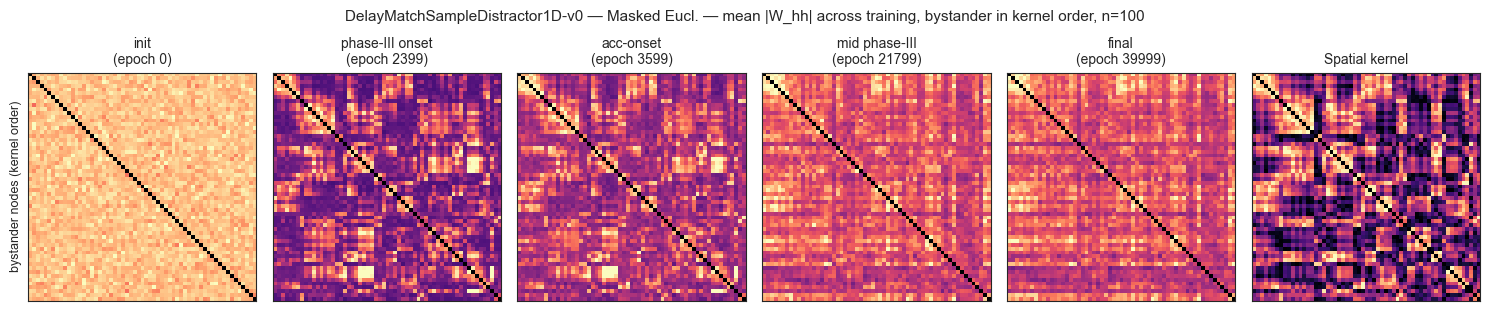

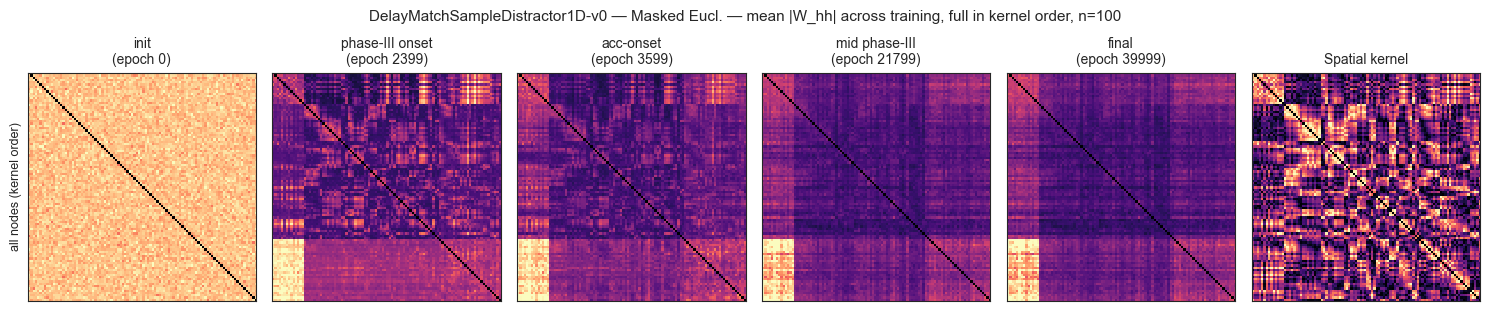

In [75]:
# ============================================================================
# W_hh matrix snapshots along training  (supports the topology + hysteresis)
# ----------------------------------------------------------------------------
# Run-mean |W_hh| at training checkpoints anchored to the hysteresis phases,
# shown in native KERNEL ORDER (nodes already ordered to match the spatial
# kernel), alongside the spatial kernel in the same order (structure-only
# companion to the model-FC figure). Two figures are produced per model: the
# bystander subgraph (the nodes the topology metrics use) and the full network.
# Each panel is pattern-normalized (per-panel robust vmax; diagonal zeroed) so
# structure is comparable across checkpoints and against the references.
#
# W_hh is NOT stored in the trajectory pickle -- it is reloaded per checkpoint
# from the model .h5 (key 'rnn.weight_hh_l0').
# ============================================================================
import h5py
from src.fmri_io import get_paths, load_kernels
import src.utils as utils

WHH_KEY = 'rnn.weight_hh_l0'
WHH_CMAP = 'magma'


def _whh_disp(M):
    """abs value, zero diagonal, robust vmax (99th pct off-diagonal)."""
    M = np.abs(np.asarray(M, float)).copy()
    np.fill_diagonal(M, 0.0)
    off = M[~np.eye(M.shape[0], dtype=bool)]
    vmax = float(np.nanpercentile(off, 99)) if off.size else 1.0
    return M, (vmax if vmax > 0 else 1.0)


def _whh_smooth(y, w=5):
    y = np.asarray(y, float)
    if len(y) < w:
        return y
    k = np.ones(w) / w
    return np.convolve(np.pad(y, w // 2, mode='edge'), k, 'valid')[:len(y)]


# spatial kernels, loaded once, in native/kernel order (structure reference)
_dd, _mdir, _fd = get_paths(model_params_name)
_kernels = load_kernels(_dd, hidden_size=100)

set_font_size(int(7 * 1.4))

for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue
        this = model_params.iloc[model_idx]
        if this.task_index != task_idx:
            continue
        ep0d = res['runs'][0]['epochs'][res['sampled_epochs'][0]]
        if ep0d['weight_kernel_similarity'] is None:      # bioRNNs only
            continue

        epochs = np.array(res['sampled_epochs']); nE = len(epochs); nr = res['n_runs']

        # phase-III onset (argmax run-mean W-K cosine) + accuracy-onset, as in
        # the topology figure, to anchor the snapshot checkpoints
        wk = np.full((nr, nE), np.nan); acc = np.full((nr, nE), np.nan)
        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                ed = run['epochs'][ep]; acc[ri, ei] = ed['accuracy']
                wkd = ed['weight_kernel_similarity']
                if wkd is not None:
                    wk[ri, ei] = wkd['cosine']
        wk_m = np.nanmean(wk, axis=0); acc_m = np.nanmean(acc, axis=0)
        onset_idx = int(np.nanargmax(_whh_smooth(wk_m)))
        floor, top = acc_m[onset_idx], acc_m[-1]; thr = floor + 0.05 * (top - floor)
        cx = np.where(acc_m[onset_idx:] >= thr)[0]
        acc_on_idx = onset_idx + int(cx[0]) if cx.size else nE - 1
        mid_idx = (acc_on_idx + nE - 1) // 2

        ck = []
        for i, lab in [(0, 'init'), (onset_idx, 'phase-III onset'),
                       (acc_on_idx, 'acc-onset'), (mid_idx, 'mid phase-III'),
                       (nE - 1, 'final')]:
            if i not in [c[0] for c in ck]:
                ck.append((i, lab))
        ck.sort()

        # run-mean |W_hh| at each checkpoint, reloaded from the model .h5
        h5path = os.path.join(modeldir, this.file_str_models)
        meanabsW = {}
        with h5py.File(h5path, 'r') as h:
            for i, _ in ck:
                ep = int(epochs[i])
                stack = np.zeros((100, 100))
                for r in range(nr):
                    stack += np.abs(h[f'run_{r}/epoch_{ep}/{WHH_KEY}'][()])
                meanabsW[i] = stack / nr

        # two figures: bystander subgraph and the full network, both kernel order
        by = np.array(res['node_subsets']['bystander'])
        N = meanabsW[ck[0][0]].shape[0]
        regions = [('bystander', np.ix_(by, by), 'bystander nodes (kernel order)'),
                   ('full', np.ix_(np.arange(N), np.arange(N)), 'all nodes (kernel order)')]

        for region_name, rix, ylab in regions:
            panels = [(f'{lab}\n(epoch {int(epochs[i])})', meanabsW[i][rix]) for i, lab in ck]
            panels.append(('Spatial kernel', _kernels[this.kernel_type][rix]))

            ncol = len(panels)
            fig, axes = plt.subplots(1, ncol, figsize=(2.5 * ncol, 2.9))
            for ax, (title, M) in zip(axes, panels):
                D, vmax = _whh_disp(M)
                ax.imshow(D, cmap=WHH_CMAP, vmin=0, vmax=vmax,
                          interpolation='nearest', aspect='equal')
                ax.set_title(title)
                ax.set_xticks([]); ax.set_yticks([])
            axes[0].set_ylabel(ylab)
            fig.suptitle(f'{task_names[task_idx]} — {this.kernel_label} — mean |W_hh| across '
                         f'training, {region_name} in kernel order, n={nr}', y=1.05)
            fig.tight_layout()
            if save_figs:
                ktag = str(this.kernel_label).replace(' ', '').replace('.', '')
                fig.savefig(os.path.join(outdir,
                            f'trajectory_Whh_snapshots_{region_name}_{task_names[task_idx]}_{ktag}{ve_file_tag}.svg'),
                            dpi=300, bbox_inches='tight', pad_inches=0.02)
            plt.show()

# Model FC snapshots across training (task)

Group **model functional connectivity** (Pearson correlation of hidden-unit activity) at the phase-anchored checkpoints, bystander subgraph in kernel order. showing **task FC** across checkpoints with empirical group task-fMRI FC at the right. Unlike W_hh, model FC is not stored in the pickle — each checkpoint is reloaded from the model `.h5` and task inference is run. Set `FC_RUNS_MAX` to cap runs for speed.

fMRI subjects selected: 100
fMRI task shape: (405, 100, 100)
fMRI rest shape: (1200, 100, 100)


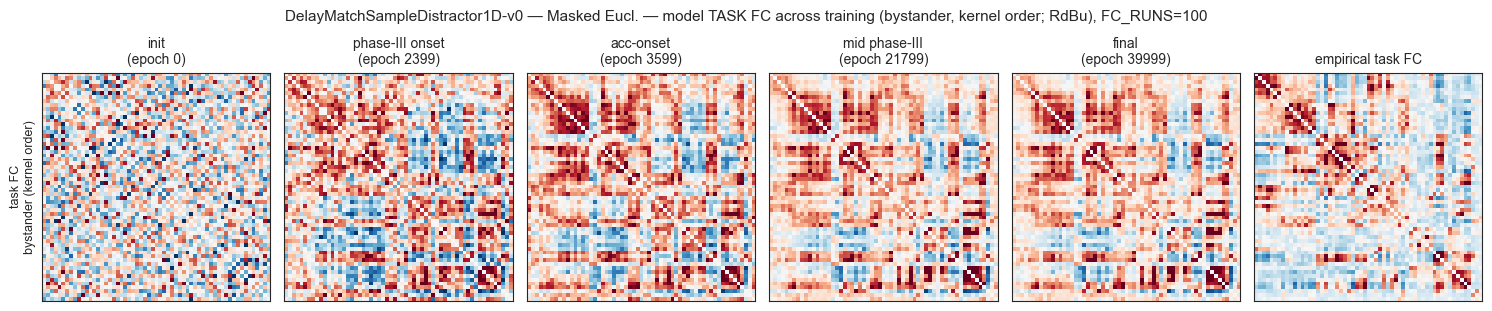

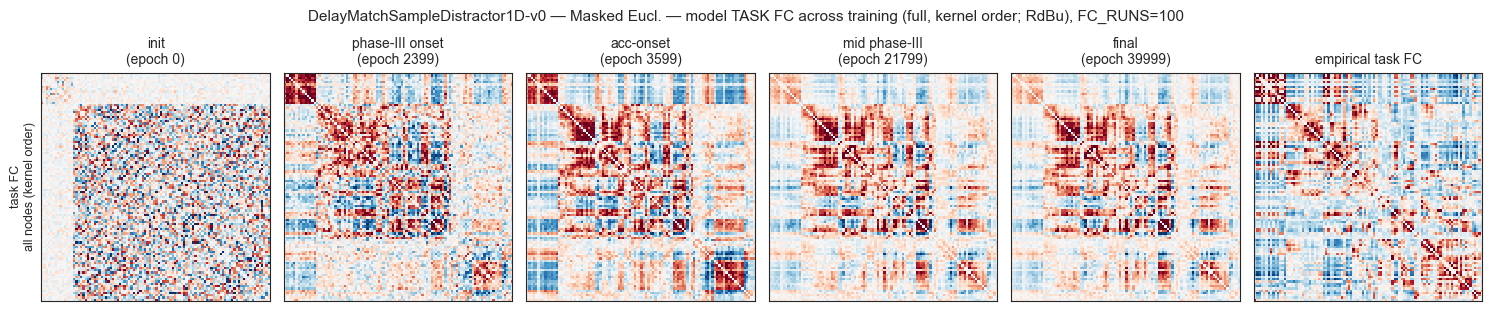

In [76]:
# ============================================================================
# Model functional-connectivity (FC) snapshots across training -- task only
# ----------------------------------------------------------------------------
# Group model TASK FC (Pearson correlation of hidden-unit activity during task
# trials) at the same phase-anchored checkpoints as the W_hh snapshots, in
# kernel order, with empirical group task-fMRI FC at the right for comparison.
# Two figures are produced per model: the bystander subgraph and the full
# network. FC is signed (RdBu diverging; per-panel symmetric robust scale
# centered on zero, diagonal zeroed).
#
# Model FC is NOT in the trajectory pickle: each checkpoint is reloaded from the
# model .h5 and task inference is run (~0.1s/run).
# ============================================================================
import importlib.util as _ilu, torch
from src.neural_network import ModelStateManager, run_testing
from src.fmri_io import get_paths, load_fmri_data
import src.utils as utils

FC_RUNS_MAX = None      # None -> all runs; set an int to cap for speed
FC_N_TRIALS = 100

# reuse create_dataset_and_rnn_shell from the trajectory script
_scriptpath = os.path.join(os.path.dirname(datadir), 'scripts',
                           'biornn_results_dynamics_trajectory.py')
_spec = _ilu.spec_from_file_location('trajmod', _scriptpath)
_Tm = _ilu.module_from_spec(_spec); _spec.loader.exec_module(_Tm)

# empirical group task-fMRI FC, native/kernel order
_dd, _mdir, _fd = get_paths(model_params_name)
_ft, _fr, _, _ = load_fmri_data(_dd, _fd, 100, hidden_size=100)
_emp_task = np.nanmean(np.stack([utils.compute_fc(_ft[:, :, s]) for s in range(_ft.shape[2])]), 0)


def _fc_smooth(y, w=5):
    y = np.asarray(y, float)
    if len(y) < w:
        return y
    k = np.ones(w) / w
    return np.convolve(np.pad(y, w // 2, mode='edge'), k, 'valid')[:len(y)]


def _fc_prep(M):
    M = np.asarray(M, float).copy(); np.fill_diagonal(M, 0.0); return M


set_font_size(int(7 * 1.4))

for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue
        this = model_params.iloc[model_idx]
        if this.task_index != task_idx:
            continue
        ep0d = res['runs'][0]['epochs'][res['sampled_epochs'][0]]
        if ep0d['weight_kernel_similarity'] is None:      # bioRNNs only
            continue

        epochs = np.array(res['sampled_epochs']); nE = len(epochs); nr = res['n_runs']
        FC_RUNS = nr if FC_RUNS_MAX is None else min(nr, FC_RUNS_MAX)

        # checkpoint anchoring (same phase-III onset logic as the W_hh cells)
        wk = np.full((nr, nE), np.nan); acc = np.full((nr, nE), np.nan)
        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                ed = run['epochs'][ep]; acc[ri, ei] = ed['accuracy']
                wkd = ed['weight_kernel_similarity']
                if wkd is not None:
                    wk[ri, ei] = wkd['cosine']
        wk_m = np.nanmean(wk, 0); acc_m = np.nanmean(acc, 0)
        oi = int(np.nanargmax(_fc_smooth(wk_m)))
        thr = acc_m[oi] + 0.05 * (acc_m[-1] - acc_m[oi])
        cx = np.where(acc_m[oi:] >= thr)[0]; ai = oi + int(cx[0]) if cx.size else nE - 1
        mi = (ai + nE - 1) // 2
        ck = []
        for i, lab in [(0, 'init'), (oi, 'phase-III onset'), (ai, 'acc-onset'),
                       (mi, 'mid phase-III'), (nE - 1, 'final')]:
            if i not in [c[0] for c in ck]:
                ck.append((i, lab))
        ck.sort()

        # reconstruct model once, then group model TASK FC per checkpoint
        mgr = ModelStateManager(os.path.join(modeldir, this.file_str_models))
        templ = mgr.load_model_states(run=0, epoch=int(epochs[ck[-1][0]]))
        dataset, rnn = _Tm.create_dataset_and_rnn_shell(this, templ, torch.device('cpu'))
        task_fc = {}
        for i, _lab in ck:
            ep = int(epochs[i]); tfc = []
            for r in range(FC_RUNS):
                rnn.load_state_dict(mgr.load_model_states(run=r, epoch=ep)); rnn.eval()
                out = run_testing(dataset=dataset, model=rnn, n_trials=FC_N_TRIALS,
                                  verbose=False, test_seed=0)
                tfc.append(utils.compute_fc(np.vstack(out[3])))
            task_fc[i] = np.nanmean(np.stack(tfc), 0)

        # two figures: bystander subgraph and the full network, both kernel order
        by = np.array(res['node_subsets']['bystander'])
        N = _emp_task.shape[0]
        regions = [('bystander', np.ix_(by, by), 'task FC\nbystander (kernel order)'),
                   ('full', np.ix_(np.arange(N), np.arange(N)), 'task FC\nall nodes (kernel order)')]

        for region_name, rix, ylab in regions:
            panels = [(f'{lab}\n(epoch {int(epochs[i])})', _fc_prep(task_fc[i][rix])) for i, lab in ck]
            panels.append(('empirical task FC', _fc_prep(_emp_task[rix])))

            ncol = len(panels)
            fig, axes = plt.subplots(1, ncol, figsize=(2.5 * ncol, 2.9))
            for ax, (title, M) in zip(axes, panels):
                v = np.nanpercentile(np.abs(M[~np.eye(M.shape[0], dtype=bool)]), 98)
                v = v if v > 0 else 1.0
                ax.imshow(M, cmap='RdBu_r', vmin=-v, vmax=v,
                          interpolation='nearest', aspect='equal')
                ax.set_title(title)
                ax.set_xticks([]); ax.set_yticks([])
            axes[0].set_ylabel(ylab)
            fig.suptitle(f'{task_names[task_idx]} — {this.kernel_label} — model TASK FC across '
                         f'training ({region_name}, kernel order; RdBu), FC_RUNS={FC_RUNS}', y=1.05)
            fig.tight_layout()
            if save_figs:
                ktag = str(this.kernel_label).replace(' ', '').replace('.', '')
                fig.savefig(os.path.join(outdir,
                            f'trajectory_modelFC_task_{region_name}_{task_names[task_idx]}_{ktag}{ve_file_tag}.svg'),
                            dpi=300, bbox_inches='tight', pad_inches=0.02)
            plt.show()